# **Project 01**

## **Bài toán số 1**

**Cài đặt**

**Import thư viện**

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
from seaborn._core.typing import default
import matplotlib.pyplot as plt
import re, os, math, unicodedata
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import skew
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import builtins
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




**Load dữ liệu lưu vào biến data frame**

In [74]:

# Load dữ liệu (tương đương spark.read.csv)
folder_path = 'Data'
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Loại bỏ trùng lặp
data = data.drop_duplicates()

**Xem thông tin chung dữ liệu**

In [75]:
# Print the shape of the dataset (rows, columns)
print("\nDataset shape:")
data.shape

# Display data types and non-null counts for each column
print("\nData types and missing values:")
data.info()

# Show summary statistics for each column (e.g., mean, std, min, max)
print("\nDescriptive statistics:")
data.describe(include='all')

# Check for missing values
print("\nMissing values per column:")
data.isnull().sum()


Dataset shape:

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   object 
 2   don_gia              7939 non-null   object 
 3   dien_tich            7939 non-null   object 
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   object 
 9   dien_tich_su_dung    3746 non-null   object 
 10  gia_m2               7939 non-null   object 
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   object 
 13  so_phong_ve_sinh     5963 non-null   object 
 14  tong_so_tang         5488 non-null   float64


tieu_de                   1
gia_ban                   2
don_gia                   2
dien_tich                 2
dia_chi                   0
mo_ta                     2
dien_thoai             3997
loai_hinh                 2
dien_tich_dat             2
dien_tich_su_dung      4195
gia_m2                    2
giay_to_phap_ly         501
so_phong_ngu              2
so_phong_ve_sinh       1978
tong_so_tang           2453
tinh_trang_noi_that    3519
huong_cua_chinh        6623
dac_diem               2746
chieu_ngang            1851
chieu_dai              1987
ma_can                 7916
ten_phan_khu_lo        7916
bieu_do_gia               0
dtype: int64

**Xem thông tin mẫu**

In [76]:
# Display the first 5 rows to understand the structure of the data
print("First rows:")
data.head(1)


First rows:


,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"3,85 tỷ","106,94 triệu/m²",36 m²,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,NaN,"Nhà ngõ, hẻm",36 m²,NaN,...,2 phòng,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5 m,8 m,NaN,NaN,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ..."


**Xử lý dữ liệu trùng --> đối với dữ liệu đã cho là các dòng không có dữ liệu trong quá trình crawl data**

In [77]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Số NaN': missing, 'Tỷ lệ (%)': missing_pct})
missing_df = missing_df[missing_df['Số NaN'] > 0].sort_values('Tỷ lệ (%)', ascending=False)
print('Các cột có giá trị thiếu:')
missing_df

Các cột có giá trị thiếu:


,Số NaN,Tỷ lệ (%)
ten_phan_khu_lo,7916,99.69
ma_can,7916,99.69
huong_cua_chinh,6623,83.40
dien_tich_su_dung,4195,52.83
dien_thoai,3997,50.33
tinh_trang_noi_that,3519,44.31
dac_diem,2746,34.58
tong_so_tang,2453,30.89
chieu_dai,1987,25.02
so_phong_ve_sinh,1978,24.91


In [78]:
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7941


**Tiền xử lý dữ liệu (Data Cleaning)**

**Xử lý đơn vị tiền tệ**

Thay các hàm udf và regexp_replace của Spark sang các hàm xử lý chuỗi của Pandas

In [79]:
def standardize_price(price_str):
    if pd.isna(price_str): return None
    price_str = str(price_str).lower().replace(',', '.')
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", price_str)
    if not nums: return None
    val = float(nums[0])
    if 'tỷ' in price_str: return val
    if 'triệu' in price_str: return val / 1000
    return val

# Áp dụng chuẩn hóa giá và diện tích
data['gia_ban'] = data['gia_ban'].apply(standardize_price)

cols_to_convert = ['dien_tich', 'dien_tich_dat', 'so_phong_ngu', 'chieu_ngang', 'tong_so_tang']
for col in cols_to_convert:
    data[col] = data[col].astype(str).str.replace('[^0-9,.]', '', regex=True).str.replace(',', '.')
    data[col] = pd.to_numeric(data[col], errors='coerce')


**Chuyển đổi các cột có đơn vị tính về dạng chỉ có số để tính toán**\
Riêng 2 cột 'don_gia', 'gia_m2' chỉ xử lý tượng trưng vì sẽ drop vì lý do ở những bước dưới

In [80]:
columns_to_convert = [
    'gia_ban', 'don_gia', 'dien_tich', 'dien_tich_dat', 'dien_tich_su_dung', 'gia_m2', 'so_phong_ngu',
    'so_phong_ve_sinh', 'chieu_ngang', 'chieu_dai'
]

for col_name in columns_to_convert:
    # 1. Chuyển sang chuỗi, loại bỏ các ký tự không phải số, dấu phẩy, dấu chấm
    # 2. Thay dấu phẩy thành dấu chấm
    # 3. Chuyển sang kiểu số (float), các giá trị không hợp lệ sẽ tự động thành NaN (tương đương null)
    data[col_name] = (
        data[col_name]
        .astype(str)
        .str.replace(r'[^0-9,.]', '', regex=True)
        .str.replace(',', '.')
    )

    # Sử dụng pd.to_numeric với errors='coerce' để chuyển chuỗi rỗng hoặc lỗi thành NaN
    data[col_name] = pd.to_numeric(data[col_name], errors='coerce')

# Hiển thị 3 dòng đầu
data[columns_to_convert].head(3)

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,chieu_ngang,chieu_dai
0,3.85,106.94,36.0,36.0,NaN,106.94,2.0,2.0,4.5,8.0
1,9.79,157.90,62.0,62.0,NaN,157.90,4.0,NaN,NaN,NaN
2,7.20,133.33,54.0,54.0,NaN,133.33,3.0,2.0,7.0,7.7


**Kiểm tra và điền các dòng giá trị không hợp lệ của chiều ngang về null**

In [81]:
def clean_invalid_dimensions_pandas(df):
    # Tạo biến tạm để tính toán
    df['dien_tich_tmp'] = np.where(
        df['chieu_ngang'].notna() & df['chieu_dai'].notna(), # Điều kiện (When)
        df['chieu_ngang'] * df['chieu_dai'],                 # Kết quả nếu True
        0                                                    # Kết quả nếu False
    )

    # Điều kiện 1: chieu_ngang > dien_tich
    cond1 = df['chieu_ngang'] > df['dien_tich']

    # Điều kiện 2: sai lệch diện tích > 0 (chỉ kiểm tra khi cả 3 cột not null)
    cond2 = (df['chieu_ngang'].notna()) & \
            (df['chieu_dai'].notna()) & \
            (df['dien_tich'].notna()) & \
            (abs(df['dien_tich'] - df['dien_tich_tmp']) > 0)

    # Nếu vi phạm bất kỳ điều kiện nào (cond1 HOẶC cond2) -> Gán NaN
    df['chieu_ngang'] = np.where(cond1 | cond2, np.nan, df['chieu_ngang'])

    # Loại bỏ cột tạm dien_tich_tmp để làm sạch DataFrame kết quả
    df = df.drop(columns=['dien_tich_tmp'])
    return df

# Sử dụng:
data = clean_invalid_dimensions_pandas(data)

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   float64
 2   don_gia              7939 non-null   float64
 3   dien_tich            7939 non-null   float64
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   float64
 9   dien_tich_su_dung    3746 non-null   float64
 10  gia_m2               7939 non-null   float64
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   float64
 13  so_phong_ve_sinh     5963 non-null   float64
 14  tong_so_tang         5488 non-null   float64
 15  tinh_trang_noi_that  4422 non-null   object

**Kiểm tra biến numerical mang giá trị 0 hoặc nhỏ hơn 0 là các giá trị invalid**

In [83]:
# Lọc các cột có kiểu dữ liệu là số (tương đương double, integer trong Spark)
numeric_df = data.select_dtypes(include=['number'])

# Đếm các giá trị bằng 0 trong các cột này
zero_and_negative_count = (numeric_df <= 0).sum()

# Hiển thị kết quả
zero_and_negative_count.to_frame(name='zero_and_negative_count').T

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,chieu_ngang,chieu_dai
zero_and_negative_count,0,0,0,0,0,0,0,0,0,0,0


**Kiểm tra null**

In [84]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

print("Số lượng giá trị Null trong các cột số:")
data[numeric_cols].isnull().sum()

Số lượng giá trị Null trong các cột số:


gia_ban                 2
don_gia                 2
dien_tich               2
dien_tich_dat           2
dien_tich_su_dung    4195
gia_m2                  2
so_phong_ngu            2
so_phong_ve_sinh     1978
tong_so_tang         2453
chieu_ngang          5573
chieu_dai            1987
dtype: int64

**Vẽ biểu đồ tương quan để xét tính đa cộng tuyến**\
Nhận xét:
- 'chieu_dai' có tương quan mạnh với 'dien_tich_dat' (0.76) -> cần drop cột 'chieu_dai' để tránh đa cộng tuyến
- Tương tự cần drop cột 'so_phong_ve_sinh', giữ lại 'so_phong_ngu', vì 'so_phong_ngu' không có Null

In [85]:
def visualize_correlation(df):
    #
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    corr_df = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numeric Features')
    plt.show()

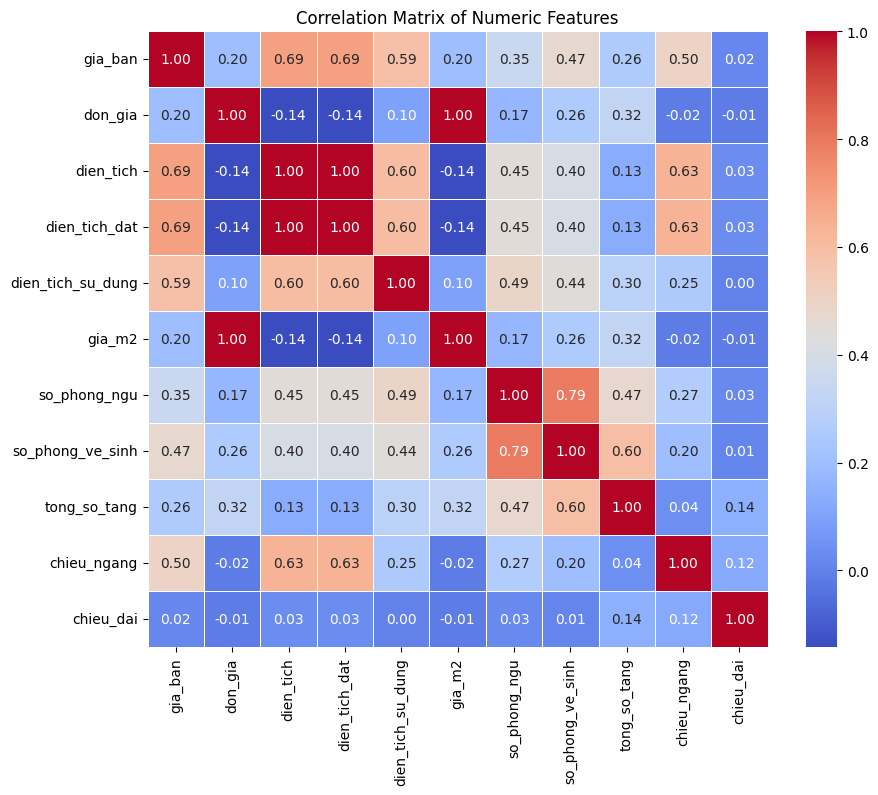

In [86]:
visualize_correlation(data)

**Drop các cột không có ý nghĩa thống kê và có sự tương quan, một số cột khác sẽ được drop sau khi trích xuất thông tin, vd: 'tieu_de', 'mo_ta', 'dia_chi', 'chieu_dai'**
- Đơn giá = giá bán/ diện tích đất
- Diện tích = diện tích đất
- Chiều dài: tương quan với Diện tích đất
- Số phòng vệ sinh tương quan với Số phòng ngủ
- Giá m2 = đơn giá
- Điện thoại, mã căn, tên phân khu/lô, biểu đồ giá: không có ý nghĩa thống kê

In [87]:
# Danh sách các cột cần loại bỏ
cols_to_drop = ['don_gia', 'dien_tich', 'so_phong_ve_sinh', 'gia_m2', 'dien_thoai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia']

# Sử dụng drop với axis=1 để xóa cột
# errors='ignore' giúp code không bị lỗi nếu một trong các cột đã bị xóa trước đó
data = data.drop(columns=cols_to_drop, errors='ignore')

# Hiển thị 3 dòng đầu (tương đương .show(3))
data.head(3)

,tieu_de,gia_ban,dia_chi,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,3.85,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,"Nhà ngõ, hẻm",36.0,NaN,Đã có sổ,2.0,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5,8.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",9.79,"Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...","Nhà ngõ, hẻm",62.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,7.20,"Đường Nơ Trang Long, Phường 13, Quận Bình Thạn...",XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"Nhà ngõ, hẻm",54.0,NaN,Đã có sổ,3.0,2.0,Hoàn thiện cơ bản,NaN,Hẻm xe hơi,NaN,7.7


**Thêm feature là 2 cột địa chỉ cũ, địa chỉ mới từ cột địa chỉ, vì địa chỉ phản ánh khu vực mặt bằng giá nên có liên quan đến giá nhà, vd nhà quận 1 thường đắt hơn nhà các quận khác, sau đó drop cột địa chi vì không còn nhu cầu phân tích thống kê**

In [88]:
# 1. Trích xuất chỉ lấy QUẬN (Bỏ qua Phường để Model tập trung hơn)
# Regex này sẽ tìm chữ "Quận..." hoặc "Huyện..." trong địa chỉ
data['quan_huyen'] = data['dia_chi'].str.extract(r'(Quận\s+[^,]+|Huyện\s+[^,]+)', expand=False)

# 2. Xử lý trường hợp không tìm thấy (NaN)
data['quan_huyen'] = data['quan_huyen'].replace(['', np.nan], 'Chưa xác định')

# 3. Loại bỏ cột dia_chi gốc
data = data.drop(columns=['dia_chi'])

# Kiểm tra thử xem danh sách Quận đã gọn chưa
print("Các quận hiện có:", data['quan_huyen'].unique())
data[['quan_huyen']].head(3)

Các quận hiện có: ['Quận Bình Thạnh' 'Chưa xác định' 'Quận Gò Vấp' 'Quận Phú Nhuận']


,quan_huyen
0,Quận Bình Thạnh
1,Quận Bình Thạnh
2,Quận Bình Thạnh


**Xử lý Null**

**Chúng ta sẽ xử lý theo thứ tự lần lượt như sau:**
- 'loai_hinh', 'dien_tich_dat', 'so_phong_ngu': xử lý null bằng cách xóa 2 dòng dữ liệu invalid
- 'tong_so_tang': được trích xuất thông tin từ 2 cột 'tieu_de' và 'mo_ta'
- 'dien_tich_su_dung' có mối tương quan với 'dien_tich_dat' và 'tong_so_tang', nên dùng model Linear Regression để dự đoán
- 'chieu_ngang' được xử lý lần lượt qua 2 phương án:\
\+ PA1: Tính dựa vào 'dien_tich_dat' và 'chieu_dai' sẵn có: chieu_ngang = dien_tich_dat/chieu_dai\
\+ PA2: Tính dựa vào median / mean tỷ lệ thực tế trong dữ liệu
→ Tính ratio = chieu_ngang / chieu_dai (hoặc ngược lại) từ các hàng có cả 2 cột không null → lấy median(ratio) → chieu_ngang ≈ sqrt(dien_tich_dat / median_ratio)
- 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem': tỉ lệ null thấp --> xử lý null bằng cách điền giá trị 'Chưa xác định', 'Hiện trạng khác'
- 'huong_cua_chinh': tỉ lệ null cao, nhưng do yếu tố ngẫu nhiên của hướng --> dùng phương pháp random

**Kiểm tra và xử lý 2 dòng dữ liệu invalid, 2 dòng này làm tăng số dòng null của tất cả các cột**

In [89]:
# 1. Lọc các dòng có 'dien_tich_dat' là Null
null_data = data[data['dien_tich_dat'].isna()]

# 2. In kết quả dạng bảng
if null_data.empty:
    print("Không có dòng nào bị Null trong cột dien_tich_dat.")
else:
    print(f"Tìm thấy {len(null_data)} dòng bị Null:")
    display(null_data.head(10))

Tìm thấy 2 dòng bị Null:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen
1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định
1814,Bad gateway Error code 502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định


In [90]:
# Xóa null các dòng invalid
data = data.dropna(subset=['dien_tich_dat'])
null_counts_df = data.isnull().sum().to_frame(name='null_counts').T
print("Bảng thống kê số lượng Null sau khi xóa dòng invalid:")
display(null_counts_df)

Bảng thống kê số lượng Null sau khi xóa dòng invalid:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen
null_counts,0,0,0,0,0,4193,499,0,2451,3517,6621,2744,5571,1985,0


**Xử lý null cho cột 'tong_so_tang', phương án như sau:**
- Dùng regex để nhận diện số lầu, lửng hoặc tầng
- Ưu tiên nếu có thông tin số tầng thì lấy số tầng trực tiếp từ text
- Tìm thông tin lầu, lửng để suy ra số tầng = lầu + lửng + 1
- Nếu không có thông tin lầu, lửng hoặc số tầng thì mặc định số tầng = 1

In [91]:
# --- Giữ nguyên hàm logic (vì đây là Python thuần) ---
def extract_floor_count(text):
    if not text or not isinstance(text, str):
        return None

    text_lower = text.lower()

    lau_variants = ['lầu', 'lẩu', 'làu', 'lâù', 'lâu']
    lung_variants = ['lửng', 'lững', 'lừng', 'lữn', 'lưng', 'lủng']

    lau_pattern = '|'.join(lau_variants)
    lung_pattern = '|'.join(lung_variants)

    tang_pattern = r'(\d+)\s*tầng'
    tang_matches = re.findall(tang_pattern, text_lower)

    if tang_matches:
        return int(tang_matches[0])

    floor_pattern = fr'(\d+)\s*({lau_pattern})'
    mezz_pattern = fr'(\d+)\s*({lung_pattern})'

    floor_matches = re.findall(floor_pattern, text_lower)
    mezz_matches = re.findall(mezz_pattern, text_lower)

    floor_numbers = set([match[0] for match in floor_matches])
    mezz_numbers = set([match[0] for match in mezz_matches])

    has_lau = any(variant in text_lower for variant in lau_variants)
    has_lung = any(variant in text_lower for variant in lung_variants)

    if floor_numbers or mezz_numbers or has_lau or has_lung:
        total_floors = 1
        for f in floor_numbers:
            total_floors += int(f)
        for m in mezz_numbers:
            total_floors += int(m)

        if has_lau and not floor_numbers:
            total_floors += 1
        if has_lung and not mezz_numbers:
            total_floors += 1

        return total_floors
    return None

# --- 1. Tạo hai cột mới bằng .apply() ---
# Pandas xử lý tương đương với withColumn + UDF
data['mo_ta_so_tang'] = data['mo_ta'].apply(extract_floor_count)
data['tieu_de_so_tang'] = data['tieu_de'].apply(extract_floor_count)

# --- 2. Imputing (Thay thế logic when/otherwise và coalesce) ---

# Case 1: Nếu tong_so_tang, tieu_de_so_tang, mo_ta_so_tang đều null -> gán bằng 1
# Sử dụng .isna() và .loc để gán giá trị có điều kiện
mask_all_null = data['tong_so_tang'].isna() & \
                data['tieu_de_so_tang'].isna() & \
                data['mo_ta_so_tang'].isna()
data.loc[mask_all_null, 'tong_so_tang'] = 1

# Case 2: Nếu tong_so_tang bị null, lấy giá trị từ mo_ta hoặc tieu_de (Coalesce)
# .fillna() của Pandas hoạt động tương tự coalesce khi áp dụng tuần tự
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['mo_ta_so_tang'])
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['tieu_de_so_tang'])

# --- 3. Hiển thị kết quả ---
cols_to_show = ["tieu_de", "tieu_de_so_tang", "mo_ta", "mo_ta_so_tang", "tong_so_tang"]
data[cols_to_show].head(10)

,tieu_de,tieu_de_so_tang,mo_ta,mo_ta_so_tang,tong_so_tang
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,NaN,🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,2.0,2.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",NaN,"CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...",4.0,4.0
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,NaN,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,2.0,2.0
3,🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN XÂY M...,NaN,#e45\n🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN...,NaN,1.0
4,Nhà hẻm cách đường mặt tiền 20m,NaN,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,NaN,1.0
5,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,2.0,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",NaN,2.0
6,Bán nhà 50m,NaN,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",3.0,3.0
7,❌ GIẢM GẤP 200TR ❌ Nhà đẹp sát City Garden Bìn...,NaN,🚨 GIÁ *** KHU 🚨\nNhà đẹp P21 Bình Thạnh – 2 tầ...,2.0,2.0
8,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...",6.0,"$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",5.0,5.0
9,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,NaN,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,4.0,4.0


**Kiểm tra và clean data đối với 'tong_so_tang' lớn hơn 8, vì nhà phố quy định thường không quá 8 (Theo Quyết định 135/2007/QĐ-UBND về kiến trúc nhà liên kế trong khu đô thị hiện hữu của TPHCM)**

In [92]:
count_high_floors = data[data['tong_so_tang'] > 8].shape[0]
print(f"Số lượng căn nhà có trên 8 tầng: {count_high_floors}")

Số lượng căn nhà có trên 8 tầng: 15


In [93]:
data = data[data['tong_so_tang'] <= 8]
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7924


**Xử lý null cho cột 'dien_tich_su_dung'**

In [94]:
# 1. Xác định điều kiện cho training_data và predict_data
# Trong Pandas, .notna() tương đương .isNotNull()
training_condition = (
    data['dien_tich_su_dung'].notna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

predict_condition = (
    data['dien_tich_su_dung'].isna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

# 2. Tạo tập Train và tập Predict
training_data = data[training_condition].copy()
predict_data = data[predict_condition].copy()

print(f"Total rows: {len(data)}")
print(f"Rows in training_data: {len(training_data)}")
print(f"Rows in predict_data: {len(predict_data)}")

# 3. Chuẩn bị Feature (X) và Target (y)
feature_cols = ["dien_tich_dat", "tong_so_tang"]
X_train = training_data[feature_cols]
y_train = training_data["dien_tich_su_dung"]
X_predict = predict_data[feature_cols]

# 4. Khởi tạo và huấn luyện model Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Dự đoán giá trị còn thiếu
if not predict_data.empty:
    y_pred = lr.predict(X_predict)

    # Chặn các giá trị âm (Capping): nếu < 0 thì lấy giá trị của dien_tich_dat
    # Tương đương logic: when(col("prediction") < 0, col("dien_tich_dat"))
    y_pred_capped = np.where(y_pred < 0, predict_data['dien_tich_dat'], y_pred)

    # Gán giá trị dự đoán vào cột dien_tich_su_dung của predict_data
    predict_data['dien_tich_su_dung'] = y_pred_capped

# 6. Gộp dữ liệu lại (Union)
# Những dòng không thỏa mãn cả 2 điều kiện trên (nếu có) cũng cần được giữ lại
other_data = data[~(training_condition | predict_condition)]

data_imputed = pd.concat([training_data, predict_data, other_data], axis=0).reset_index(drop=True)

# 7. Kiểm tra lại số lượng Null
print("\nSố lượng Null còn lại trong cột 'dien_tich_su_dung':")
print(data_imputed['dien_tich_su_dung'].isna().sum())

# Hiển thị mẫu kết quả
print("\nMẫu dữ liệu sau khi điền khuyết:")
display(predict_data[feature_cols + ['dien_tich_su_dung']].head(10))

# Cập nhật lại biến data chính
data = data_imputed

Total rows: 7924
Rows in training_data: 3737
Rows in predict_data: 4187

Số lượng Null còn lại trong cột 'dien_tich_su_dung':
0

Mẫu dữ liệu sau khi điền khuyết:


,dien_tich_dat,tong_so_tang,dien_tich_su_dung
0,36.0,2.0,50.498670
1,62.0,4.0,189.137132
2,54.0,2.0,90.563910
3,83.0,1.0,114.730241
7,26.0,2.0,28.240203
10,60.0,4.0,184.685439
14,48.0,2.0,77.208830
15,70.0,3.0,166.560682
21,40.0,4.0,140.168505
22,72.0,2.0,130.629151


**Xử lý null cho cột 'chieu_ngang' --> PA1**

In [95]:
# 1. Tính toán lại chieu_ngang dựa trên dien_tich_dat và chieu_dai
# Điều kiện: diện tích đất và chiều dài có giá trị, nhưng chiều ngang bị thiếu (Null)
mask = (data['dien_tich_dat'].notna()) & \
       (data['chieu_ngang'].isna()) & \
       (data['chieu_dai'].notna()) & \
       (data['chieu_dai'] > 0) & \
       (data['dien_tich_dat'] > 0)

# Áp dụng công thức: chiều ngang = diện tích / chiều dài
data.loc[mask, 'chieu_ngang'] = data['dien_tich_dat'] / data['chieu_dai']

# 2. Đếm số lượng Null ở tất cả các cột và hiển thị dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi tính toán chiều ngang:")
display(null_summary)

Bảng thống kê số lượng Null sau khi tính toán chiều ngang:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,1840,1982,0,1030,4302


**Xử lý null cho cột 'chieu_ngang' --> PA2**

In [96]:
# --- Bước 1: Tính tỷ lệ ngang / dài trung vị (Median Ratio) ---
# Lọc các hàng có đủ ngang và dài (>0) để tính tỷ lệ mẫu
valid_mask = (data['chieu_ngang'].notna()) & (data['chieu_dai'] > 0)
ratio_ngang_dai = data.loc[valid_mask, 'chieu_ngang'] / data.loc[valid_mask, 'chieu_dai']

# Tính median (tương đương percentile_approx 0.5)
median_ratio = ratio_ngang_dai.median()

# Fallback nếu không tính được median
if pd.isna(median_ratio) or median_ratio <= 0:
    median_ratio = 0.3

print(f"Median Ratio (Ngang/Dài) tính được: {median_ratio:.4f}")

# --- Bước 2: Impute cho các hàng thiếu cả ngang + dài nhưng có dien_tich_dat ---
# Điều kiện: Cả ngang và dài đều Null, nhưng diện tích đất thì có
impute_mask = (data['chieu_ngang'].isna()) & \
              (data['chieu_dai'].isna()) & \
              (data['dien_tich_dat'].notna())

# Tính toán giá trị tạm thời
# Công thức: diện tích = ngang * dài => diện tích = (dài * ratio) * dài => dài = sqrt(diện tích / ratio)
# Ngược lại: ngang = sqrt(diện tích * ratio)
temp_ngang = np.sqrt(data.loc[impute_mask, 'dien_tich_dat'] * median_ratio)
temp_dai = data.loc[impute_mask, 'dien_tich_dat'] / temp_ngang

# Cập nhật vào dataframe gốc (tương đương coalesce)
data.loc[impute_mask, 'chieu_ngang'] = temp_ngang
data.loc[impute_mask, 'chieu_dai'] = temp_dai

# --- Bước 3: Kiểm tra lại kết quả ---
null_summary = data.isnull().sum().to_frame(name='null_count').T
print("\nSố lượng Null sau khi xử lý ngang/dài đồng thời:")
display(null_summary)

Median Ratio (Ngang/Dài) tính được: 0.3400

Số lượng Null sau khi xử lý ngang/dài đồng thời:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,0,142,0,1030,4302


**Xử lý null cho các cột 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem'**

In [97]:
# 1. Điền giá trị khuyết cho các cột phân loại bằng dictionary
fill_values = {
    'giay_to_phap_ly': 'Chưa xác định',
    'tinh_trang_noi_that': 'Chưa xác định',
    'dac_diem': 'Hiện trạng khác'
}

data = data.fillna(value=fill_values)

# 2. Kiểm tra lại số lượng Null của tất cả các cột dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi fillna:")
display(null_summary)

Bảng thống kê số lượng Null sau khi fillna:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,0,0,0,0,6609,0,0,142,0,1030,4302


**Xử lý null cho cột 'huong_cua_chinh'**

In [98]:
def impute_with_distribution_pandas(df, col='huong_cua_chinh', random_state=42):
    """
    Điền null bằng random sample theo distribution thực tế sử dụng Pandas & Numpy.
    """
    # 1. Tính toán phân phối xác suất (tương đương value_counts + prob trong Spark)
    # normalize=True sẽ tự động chia cho tổng số lượng non-null
    dist = df[col].value_counts(normalize=True)

    values = dist.index.tolist()
    probs = dist.values.tolist()

    # 2. Xác định các vị trí bị Null
    is_null = df[col].isna()
    null_count = is_null.sum()

    if null_count > 0:
        # 3. Tạo mẫu ngẫu nhiên dựa trên phân phối đã tính
        rng = np.random.default_rng(random_state)
        random_values = rng.choice(values, size=null_count, p=probs)

        # 4. Điền các giá trị ngẫu nhiên vào đúng các vị trí Null
        df.loc[is_null, col] = random_values

    return df

# Thực hiện điền khuyết
data = impute_with_distribution_pandas(data)

# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,142,0,1030,4302


**Xử lý khoảng trắng cho giá trị trong các cột category để tránh lỗi khi chạy thuật toán**

In [99]:
# 1. Giữ nguyên hàm logic sanitize_string (vì là Python thuần)
def sanitize_string(s):
    if s is None or pd.isna(s): # Kiểm tra thêm pd.isna cho chắc chắn trong Pandas
        return None

    s = str(s).lower()

    # Loại bỏ dấu tiếng Việt
    s = unicodedata.normalize('NFKD', s)
    s = "".join([c for c in s if not unicodedata.combining(c)])
    s = s.replace('đ', 'd').replace('Đ', 'D')

    # Thay thế ký tự đặc biệt và khoảng trắng
    s = re.sub(r'[^\w\s]', '_', s)
    s = re.sub(r'[\s,:\\[\]{}]+', '_', s)

    # Dọn dẹp dấu gạch dưới thừa
    s = re.sub(r'_+', '_', s)
    s = s.strip('_')

    return s

# 2. Danh sách các cột phân loại
categorical_cols = [
    'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
    'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi'
]

# 3. Áp dụng cho các cột trong danh sách bằng .apply()
# Pandas cho phép lọc các cột tồn tại rất dễ dàng
existing_cols = [c for c in categorical_cols if c in data.columns]

for col_name in existing_cols:
    data[col_name] = data[col_name].apply(sanitize_string)

# 4. Hiển thị mẫu dữ liệu sau khi làm sạch
print("Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:")
display(data[existing_cols].head(5))

Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:


,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem
0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac
1,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac
2,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi
3,nha_mat_pho_mat_tien,da_co_so,noi_that_day_du,dong,hien_trang_khac
4,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi


**Copy data cho project 1**

In [100]:
# Danh sách các cột cần giữ lại (Đã cập nhật: bỏ dia_chi_cu/moi, thêm quan_huyen)
selected_columns = [
    'tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 
    'tong_so_tang', 'so_phong_ngu', 'loai_hinh', 'giay_to_phap_ly', 
    'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 
    'quan_huyen', # Dùng cột này thay cho dia_chi_cu/moi
    'gia_ban'
]

# Chạy dòng này sẽ không còn lỗi nữa
data = data[selected_columns].copy()

**Copy data cho project 2 (chưa xử lý outlier, skewness)**

In [101]:
data_pr2_1 = data.copy()

**Kiểm tra lại dữ liệu**

In [102]:
# Hiển thị cấu trúc dữ liệu và 5 dòng đầu tiên để kiểm tra
print(f"Kích thước dữ liệu sau khi chọn lọc: {data.shape}")
data.head(5)

Kích thước dữ liệu sau khi chọn lọc: (7924, 14)


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,quan_huyen,gia_ban
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,Quận Bình Thạnh,2.85
1,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",120.0,166.0,5.714286,2.0,5.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac,Quận Bình Thạnh,13.00
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi,Quận Bình Thạnh,11.20
3,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...","$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",80.0,320.0,4.000000,5.0,9.0,nha_mat_pho_mat_tien,da_co_so,noi_that_day_du,dong,hien_trang_khac,Quận Bình Thạnh,25.80
4,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,68.0,163.0,3.885714,4.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi,Quận Bình Thạnh,11.30


In [103]:
# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,quan_huyen,gia_ban
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Kiểm tra lại tương quan/ đa cộng tuyến**

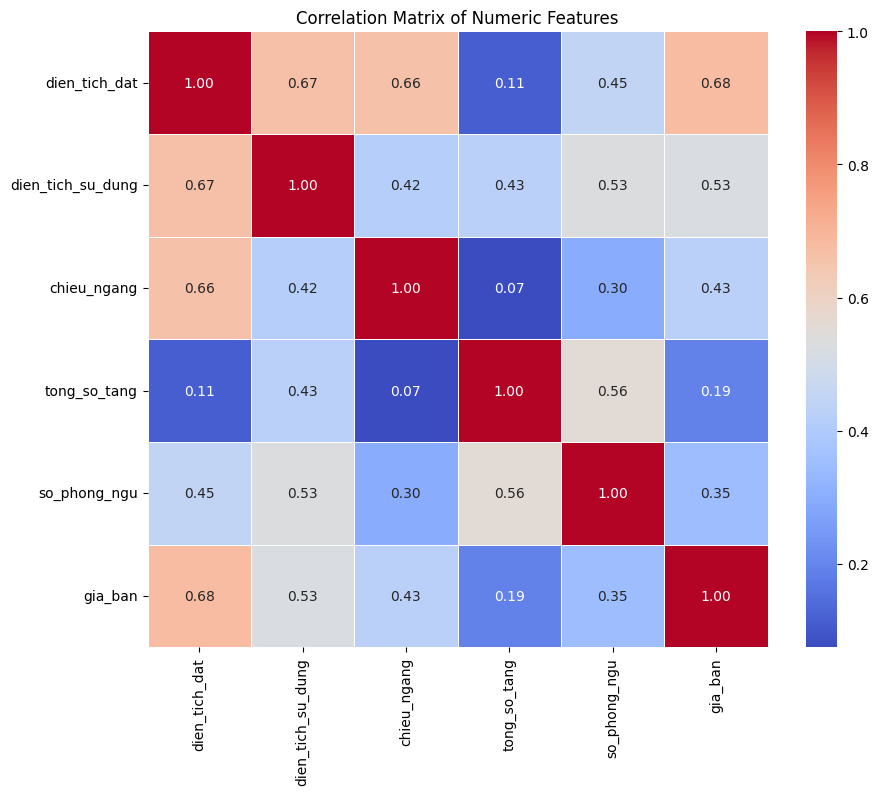

In [104]:
visualize_correlation(data)

**Xem hình dạng phân phối của dữ liệu**

In [105]:
def visualize_skewness_pandas(df):

    # Xác định danh sách cột và số lượng
    columns = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = len(columns)
    num_columns_grid = 3 # Số cột trong lưới biểu đồ (layout)
    num_rows_grid = math.ceil(num_cols / num_columns_grid) # Tự động tính số hàng cần thiết

    # Cấu hình kích thước biểu đồ tổng thể
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(columns, start=1):
        plt.subplot(num_rows_grid, num_columns_grid, i)

        # Vẽ histogram kết hợp đường KDE (biểu thị mật độ phân phối)
        sns.histplot(df[column], kde=True)

        plt.title(f"Distribution of {column}", fontsize=12)
        plt.xlabel("") # Ẩn label trục X để biểu đồ thoáng hơn
        plt.ylabel("Frequency")

    # 3. Tối ưu khoảng cách giữa các biểu đồ con
    plt.tight_layout()
    plt.show()

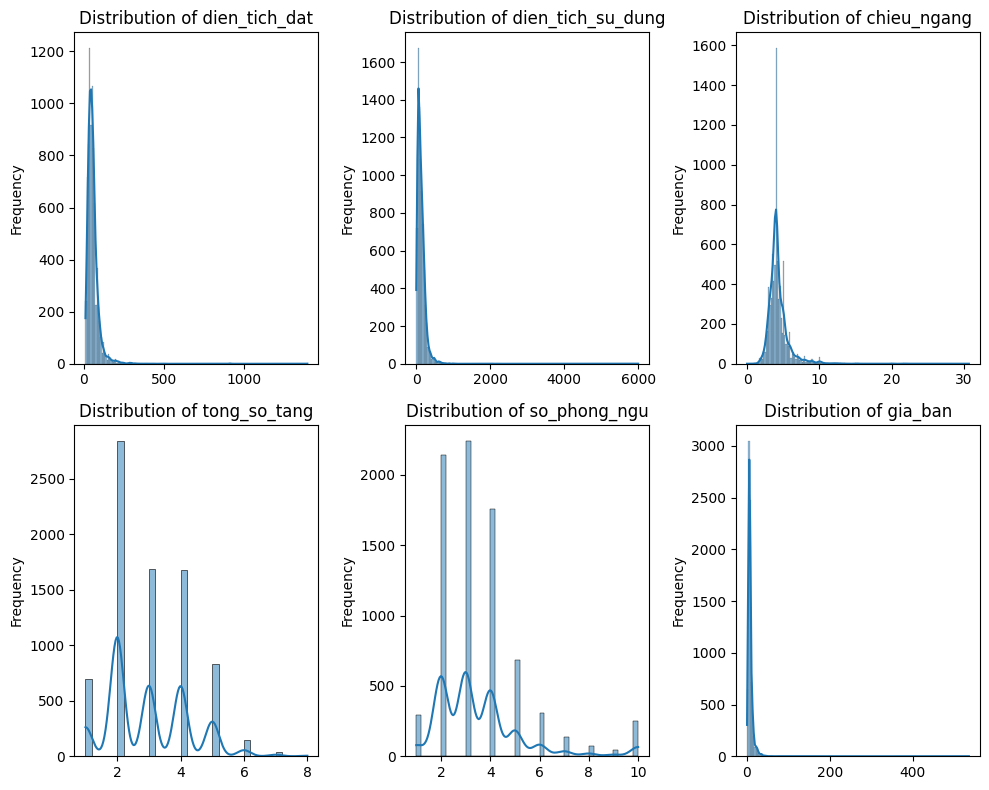

In [106]:
visualize_skewness_pandas(data)

**Kiểm tra outlier**

In [107]:
def visualize_outliers_pandas(df):

    # Xác định các cột số (numeric)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    # 2. Tự động tính toán lưới biểu đồ (layout)
    num_plots = len(numeric_cols)
    num_cols_grid = 3 # Số cột biểu đồ mỗi hàng
    num_rows_grid = math.ceil(num_plots / num_cols_grid)

    # 3. Vẽ biểu đồ
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)

        # Vẽ Boxplot
        sns.boxplot(y=df[column])

        plt.title(f'Box Plot of {column}', fontsize=12)
        plt.ylabel('')

    # 4. Tối ưu hiển thị
    plt.tight_layout()
    plt.show()

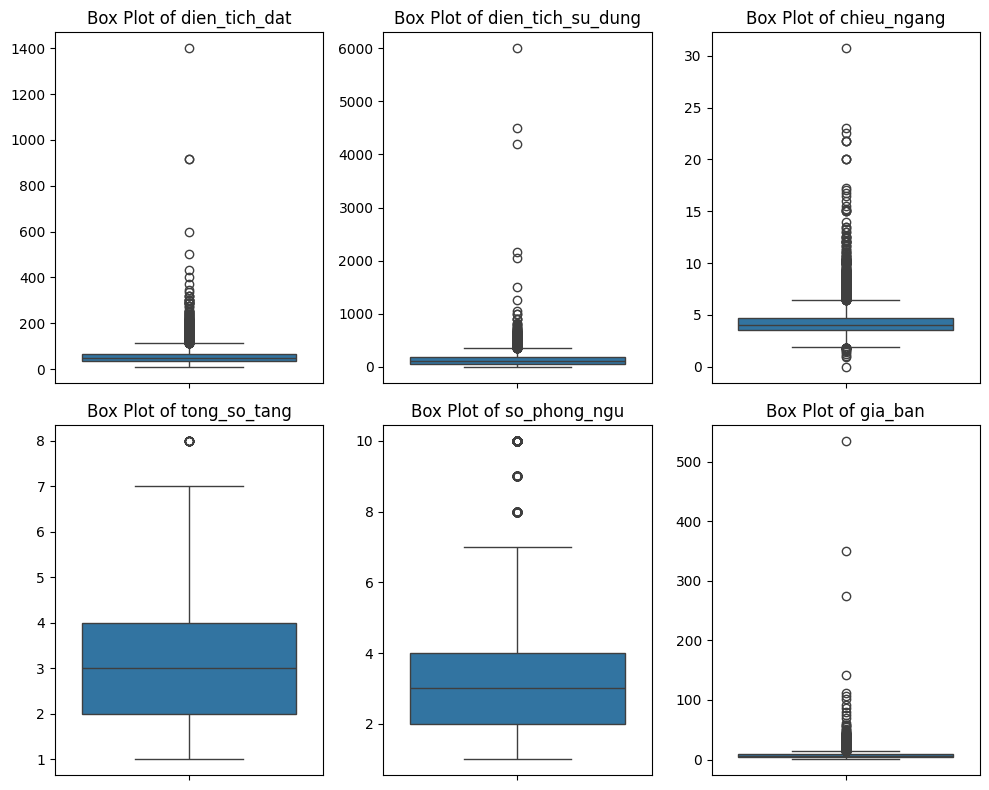

In [108]:
visualize_outliers_pandas(data)

**Xử lý outlier (Trimming)**

In [109]:
def trim_outliers_pandas(df, columns, lower_percentile=0.001, upper_percentile=0.99):
    """
    Xử lý outlier bằng phương pháp Trimming (Loại bỏ dòng) sử dụng Pandas.
    - columns: Danh sách các cột cần xử lý
    - lower_percentile: Ngưỡng dưới (0.0 đến 1.0)
    - upper_percentile: Ngưỡng trên (0.0 đến 1.0)
    """
    df_initial_count = len(df)

    # Tạo một bản sao để tránh SettingWithCopyWarning
    df_trimmed = df.copy()

    for col_name in columns:
        if col_name not in df_trimmed.columns:
            print(f"Warning: Column '{col_name}' not found in DataFrame. Skipping.")
            continue

        # Ensure the column is numeric before calculating quantiles
        if df_trimmed[col_name].dtype == 'object':
            df_trimmed[col_name] = pd.to_numeric(df_trimmed[col_name], errors='coerce')

        # Drop rows where the current column is NaN, as quantiles cannot be calculated reliably
        df_trimmed_for_quantile = df_trimmed.dropna(subset=[col_name])

        if len(df_trimmed_for_quantile) == 0:
            print(f"Warning: Column '{col_name}' became entirely NaN after numeric conversion. Cannot calculate quantiles.")
            continue

        # 1. Tính toán giá trị tại các ngưỡng bách phân vị
        lower_limit = df_trimmed_for_quantile[col_name].quantile(lower_percentile)
        upper_limit = df_trimmed_for_quantile[col_name].quantile(upper_percentile)

        if pd.isna(lower_limit) or pd.isna(upper_limit):
            print(f"Warning: Quantile limits for '{col_name}' are NaN [{lower_limit} - {upper_limit}]. Skipping trimming for this column.")
            continue

        # 2. Xác định các dòng là outlier để thống kê
        outliers = df_trimmed[(df_trimmed[col_name] < lower_limit) |
                              (df_trimmed[col_name] > upper_limit)]

        outlier_count = len(outliers)
        per_cent = (outlier_count / df_initial_count) * 100

        print(f"Cột {col_name}: Ngưỡng lọc [{lower_limit:.4f} - {upper_limit:.4f}]")
        print(f"Tỉ lệ loại bỏ: {per_cent:.4f}%")

        # 3. Loại bỏ (Filter) các dòng vượt quá ngưỡng
        df_trimmed = df_trimmed[(df_trimmed[col_name] >= lower_limit) &
                                (df_trimmed[col_name] <= upper_limit)]

    print(f"Tổng số dòng sau khi lọc: {len(df_trimmed)} (Giảm {df_initial_count - len(df_trimmed)} dòng)")

    return df_trimmed

In [110]:
# 1. Nới lỏng percentile để giữ lại dữ liệu đặc trưng của các Quận
lower_percentile = 0.001 # Chỉ xóa 0.1% nhà quá nhỏ
upper_percentile = 0.99  # Chỉ xóa 1% nhà quá ảo (giữ lại 99% dữ liệu)

# 2. Thêm cột 'dien_tich_dat' vào danh sách cần lọc (vì nó cũng ảnh hưởng lớn)
cols_to_fix = ["dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "gia_ban"]

# 3. Áp dụng trim
data = trim_outliers_pandas(data, cols_to_fix, lower_percentile, upper_percentile)

print(f"Số lượng dữ liệu còn lại sau khi lọc: {len(data)}")

Cột dien_tich_dat: Ngưỡng lọc [10.0000 - 200.0000]
Tỉ lệ loại bỏ: 0.8455%
Cột dien_tich_su_dung: Ngưỡng lọc [3.7101 - 470.0000]
Tỉ lệ loại bỏ: 1.0853%
Cột chieu_ngang: Ngưỡng lọc [1.8031 - 9.0253]
Tỉ lệ loại bỏ: 1.0853%
Cột gia_ban: Ngưỡng lọc [1.1000 - 25.5480]
Tỉ lệ loại bỏ: 1.0601%
Tổng số dòng sau khi lọc: 7601 (Giảm 323 dòng)
Số lượng dữ liệu còn lại sau khi lọc: 7601


**Copy data cho project 2 (đã xử lý outlier, chưa xử lý skewness)**

In [111]:
data_pr2_2 = data.copy()

**Xử lý skew các biến numerical**

Hàm xử lý và trả kết quả về là data đã được xử lý skew giúp model học tốt hơn

In [112]:
def analyze_numerical_skewness_pandas(df, skew_threshold=0.5):
    print("="*80)
    print("NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)")
    print("="*80)

    # Lấy các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    results = {}

    for num_col in numeric_cols:
        # Tính skewness (Pandas bỏ qua NaN mặc định)
        skew_val = df[num_col].skew()

        if pd.isna(skew_val):
            skew_level = "N/A"
        elif abs(skew_val) <= 0.5:
            skew_level = "NORMAL (Nearly symmetric)"
        elif abs(skew_val) <= 1.0:
            skew_level = "MODERATE (Moderately skewed)"
        else:
            skew_level = "HIGH (Highly skewed)"

        results[num_col] = {
            "skewness": skew_val,
            "skew_level": skew_level,
            "needs_transform": abs(skew_val) > skew_threshold if not pd.isna(skew_val) else False
        }

        print(f"\n📊 {num_col}:")
        print(f"   Skewness: {skew_val:.4f} ({skew_level})")
        print(f"   Needs Transform: {'✅ YES' if results[num_col]['needs_transform'] else '❌ NO'}")

    return results

In [113]:
def transform_numerical_variables_pandas(df, transform_plan):
    df_transformed = df.copy()
    transformation_log = {}
    
    print("\n" + "="*80)
    print("APPLYING LOG TRANSFORMATIONS (FOR HIGH SENSITIVITY)")
    print("="*80)

    for col_name, method in transform_plan.items():
        if col_name not in df.columns:
            continue

        try:
            # ÉP TẤT CẢ VỀ LOG1P ĐỂ TĂNG ĐỘ NHẠY
            # (log1p giúp xử lý tốt cả trường hợp có số 0)
            new_col = f"{col_name}_log"
            df_transformed[new_col] = np.log1p(df[col_name])
            
            # Tính độ lệch skewness sau khi Log
            skew_after = df_transformed[new_col].skew()
            
            print(f"✅ Applied LOG transform to {col_name} → {new_col}")
            print(f"   Skewness after: {skew_after:.4f}")

        except Exception as e:
            print(f"❌ Error transforming {col_name}: {e}")

    # Vì dùng Log nên không cần best_lambda nữa, trả về 0 để đánh dấu
    return df_transformed, 0

In [114]:
def complete_skew_transform_pipeline_pandas(df, numerical_skew_threshold=0.5):
    # 1. Phân tích (vẫn giữ để xem thông tin)
    skew_results = analyze_numerical_skewness_pandas(df, numerical_skew_threshold)

    # 2. LẬP KẾ HOẠCH BIẾN ĐỔI (ĐÃ SỬA: ÉP BUỘC CÁC CỘT QUAN TRỌNG)
    transform_plan = {}
    
    # Những cột "Sống còn" bắt buộc phải Log để Model nhạy
    essential_cols = ['dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'gia_ban']
    
    for col in essential_cols:
        if col in df.columns:
            transform_plan[col] = "log" # Ép dùng log hết

    # Với các cột số còn lại (số tầng, phòng ngủ...), nếu lệch thì mới biến đổi
    for col_name, stats in skew_results.items():
        if col_name not in essential_cols and stats.get("needs_transform"):
            transform_plan[col_name] = "log"

    # --- Phần còn lại giữ nguyên ---
    df_processed = df.copy()
    best_lambda_gia_ban = 1

    if transform_plan:
        # Gọi hàm transform mà m vừa sửa ở trên
        df_processed, best_lambda_gia_ban = transform_numerical_variables_pandas(df, transform_plan)
    else:
        print("No transformations needed.")

    print("\n" + "="*80)
    print(f"Original columns: {len(df.columns)}")
    print(f"New columns: {len(df_processed.columns)}")

    return df_processed, best_lambda_gia_ban

In [115]:
# Sử dụng
df_transformed, best_lambda_gia_ban = complete_skew_transform_pipeline_pandas(data)
print(f"Kích thước dữ liệu sau transform: {df_transformed.shape}")
df_transformed.head(5)

NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)

📊 dien_tich_dat:
   Skewness: 1.2649 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 dien_tich_su_dung:
   Skewness: 1.0427 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 chieu_ngang:
   Skewness: 1.2532 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 tong_so_tang:
   Skewness: 0.5188 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 so_phong_ngu:
   Skewness: 1.7001 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 gia_ban:
   Skewness: 1.6194 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

APPLYING LOG TRANSFORMATIONS (FOR HIGH SENSITIVITY)
✅ Applied LOG transform to dien_tich_dat → dien_tich_dat_log
   Skewness after: -0.2846
✅ Applied LOG transform to dien_tich_su_dung → dien_tich_su_dung_log
   Skewness after: -0.6396
✅ Applied LOG transform to chieu_ngang → chieu_ngang_log
   Skewness after: 0.3671
✅ Applied LOG transform to gia_ban → gia_ban_log
   Skewness after: 0.2143
✅ Applied LOG transform to tong_so

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,quan_huyen,gia_ban,dien_tich_dat_log,dien_tich_su_dung_log,chieu_ngang_log,gia_ban_log,tong_so_tang_log,so_phong_ngu_log
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,Quận Bình Thạnh,2.85,2.944439,2.944439,1.386294,1.348073,0.693147,1.098612
1,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",120.0,166.0,5.714286,2.0,5.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac,Quận Bình Thạnh,13.00,4.795791,5.117994,1.904237,2.639057,1.098612,1.791759
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi,Quận Bình Thạnh,11.20,4.100989,4.100989,1.833643,2.501436,1.386294,1.609438
4,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,68.0,163.0,3.885714,4.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi,Quận Bình Thạnh,11.30,4.234107,5.099866,1.586315,2.509599,1.609438,1.609438
8,"Đinh Bộ Lĩnh giáp Điện Biên Phủ ,P 15 ,Bình Th...","Đinh Bộ Lĩnh giáp Điện Biên Phủ .Phường 15 , B...",130.0,130.0,5.416667,2.0,10.0,nha_ngo_hem,da_co_so,hoan_thien_co_ban,dong_nam,hien_trang_khac,Quận Bình Thạnh,10.80,4.875197,4.875197,1.858899,2.468100,1.098612,2.397895


**Xem biểu đồ phân bố dữ liệu các cột sau khi đã xử lý skew**

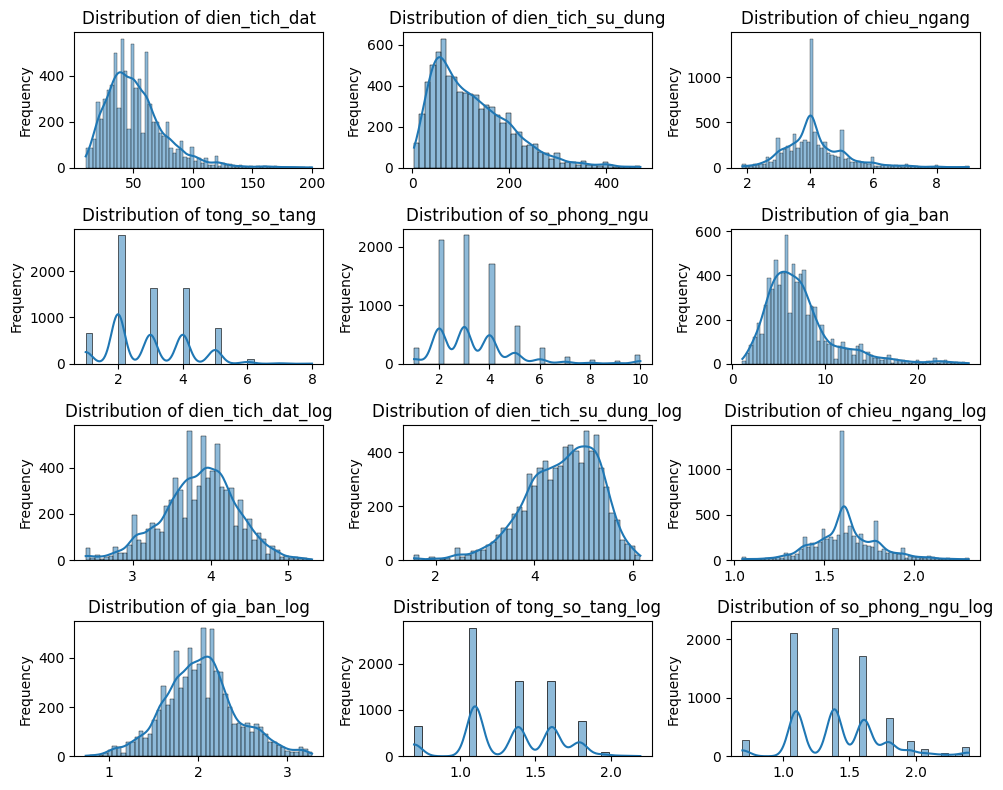

In [116]:
visualize_skewness_pandas(df_transformed)

**Kiểm tra outlier sau xử lý skew**

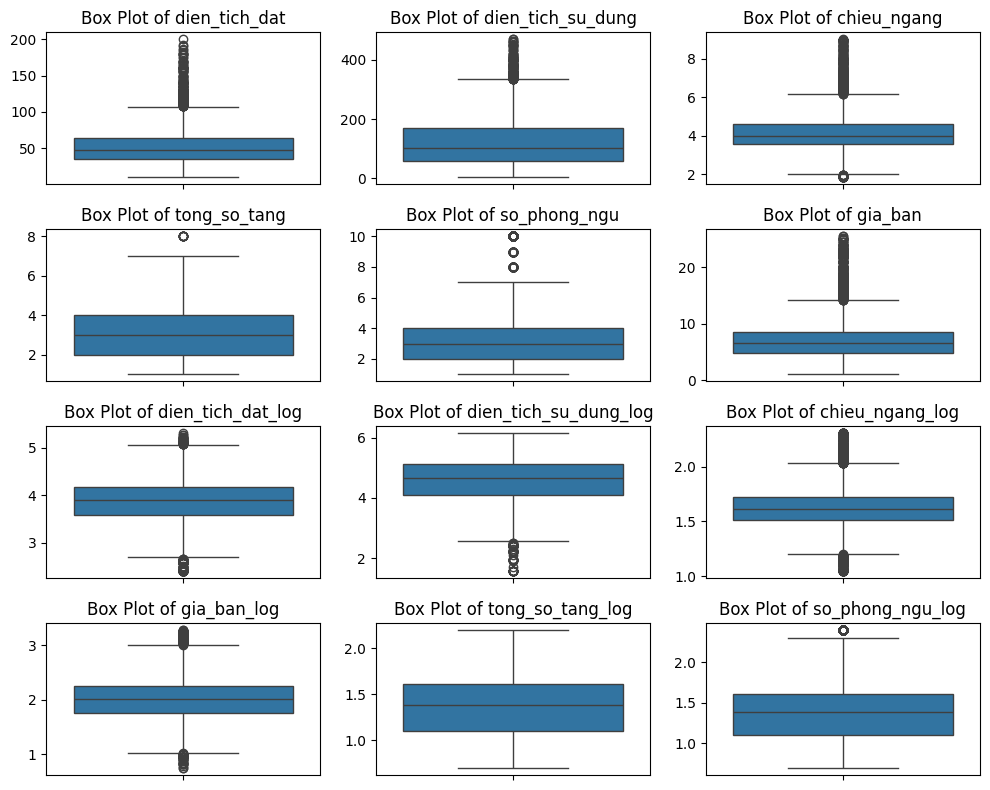

In [117]:
visualize_outliers_pandas(df_transformed)

**Copy data cho project 2 (đã xử lý outlier + skewness)**:

In [118]:
data_pr2_3 = df_transformed.copy()

**Xác định các biến numerical và categorical để chuẩn hóa trước khi training**

In [119]:
def get_numerical_for_ml(df):
    """
    Lấy danh sách các cột số cho ML, ưu tiên các cột đã được biến đổi (_log, _sqrt, _boxcox)
    và loại bỏ hoàn toàn các cột liên quan đến 'gia_ban'.
    """
    # Lấy tất cả các cột có kiểu dữ liệu là số (int, float, long, v.v.)
    all_numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Xác định các cột đã được biến đổi bằng Regex
    pattern = r"^(.*)(_log|_sqrt|_boxcox)$"
    transformed_map = {}

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        if match:
            root_name = match.group(1)
            transformed_map[root_name] = col

    # Logic lọc và ưu tiên
    numerical_cols_for_ml = []
    seen_roots = set()

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        # Nếu là cột biến đổi thì lấy root, nếu không thì lấy chính nó
        root = match.group(1) if match else col

        # Kiểm tra nếu root chứa "gia_ban" thì bỏ qua hoàn toàn (Target leakage)
        if "gia_ban" in root:
            continue

        if root not in seen_roots:
            # Nếu gốc này có bản biến đổi trong map, lấy bản biến đổi đó
            if root in transformed_map:
                numerical_cols_for_ml.append(transformed_map[root])
            else:
                # Nếu không có bản biến đổi, lấy tên gốc
                numerical_cols_for_ml.append(root)

            seen_roots.add(root)

    return numerical_cols_for_ml

In [120]:
numerical_features = get_numerical_for_ml(df_transformed)
categorical_features = df_transformed.select_dtypes(include=['object']).drop(['tieu_de', 'mo_ta'], axis=1).columns.tolist()

**Chuẩn hóa các feature**
- Áp dụng Robust Scaler cho các biến numerical
- Áp dụng OneHot Encoder cho các biến categorical


In [121]:
# Pipeline xử lý số: Điền khuyết (Imputer) -> Chuẩn hóa (RobustScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0)))
])

In [122]:
# Redefine categorical_transformer to include a string conversion step
categorical_transformer_fixed = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('to_string', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Redefine preprocessor with the fixed categorical_transformer
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer_fixed, categorical_features)
    ])

In [123]:
normalized_model = Pipeline(steps=[('preprocessor', preprocessor_fixed)])
normalized_matrix = normalized_model.fit_transform(df_transformed)

In [124]:
# Get the preprocessor from the normalized_model
preprocessor = normalized_model.named_steps['preprocessor']

# Get numerical feature names (they remain the same after scaling/imputing)
# numerical_output_features = numerical_features
numerical_output_features = [f'{col}_scaled' for col in numerical_features]
# Get categorical feature names from the OneHotEncoder step
# Access the 'cat' pipeline within the preprocessor, then the 'onehot' step within that pipeline
pre_categorical_output_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
categorical_output_features = [f'{col}_encoded' for col in pre_categorical_output_features]
# Combine numerical and categorical feature names
feature_names = list(numerical_output_features) + list(categorical_output_features)
# Convert the sparse matrix to a dense array and then to a Pandas DataFrame
normalized_df = pd.DataFrame(normalized_matrix.toarray(), columns=feature_names)
#
df_transformed = df_transformed.reset_index(drop=True)
df_transformed_combined = pd.concat([df_transformed, normalized_df], axis=1)

# Display the first 5 rows
normalized_df.head(5)

,dien_tich_dat_log_scaled,dien_tich_su_dung_log_scaled,chieu_ngang_log_scaled,tong_so_tang_log_scaled,so_phong_ngu_log_scaled,loai_hinh_nha_biet_thu_encoded,loai_hinh_nha_mat_pho_mat_tien_encoded,loai_hinh_nha_ngo_hem_encoded,loai_hinh_nha_pho_lien_ke_encoded,giay_to_phap_ly_chua_xac_dinh_encoded,...,dac_diem_hem_xe_hoi_encoded,dac_diem_hien_trang_khac_encoded,dac_diem_nha_chua_hoan_cong_encoded,dac_diem_nha_dinh_quy_hoach_lo_gioi_encoded,dac_diem_nha_nat_encoded,dac_diem_nha_no_hau_encoded,dac_diem_nha_top_hau_encoded,quan_huyen_Quận Bình Thạnh_encoded,quan_huyen_Quận Gò Vấp_encoded,quan_huyen_Quận Phú Nhuận_encoded
0,-1.603371,-1.642017,-1.071073,-1.356915,-0.563171,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.529901,0.446653,1.415017,-0.563171,0.793745,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.354002,-0.530634,1.076168,0.000000,0.436829,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.579294,0.429234,-0.110986,0.436829,0.436829,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.664291,0.213339,1.197394,-0.563171,1.980325,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Train/ Test Split**

In [143]:
# 1. Tạo bản sao dữ liệu sạch
df_final = df_transformed.copy()

# 2. Khởi tạo X và đưa diện tích về Logarit
X = pd.DataFrame()
X['dien_tich_dat_log_scaled'] = np.log1p(df_final['dien_tich_dat'])
X['dien_tich_su_dung_log_scaled'] = np.log1p(df_final['dien_tich_su_dung'])

# LẤY DỮ LIỆU THẬT Ở ĐÂY (Thay vì gán 0)
X['tong_so_tang_log_scaled'] = np.log1p(df_final['tong_so_tang'].fillna(1)) # Mặc định ít nhất 1 tầng
X['so_phong_ngu_log_scaled'] = np.log1p(df_final['so_phong_ngu'].fillna(1)) 
X['chieu_ngang_log_scaled'] = np.log1p(df_final['chieu_ngang'].fillna(4)) # Mặc định ngang 4m

# 3. Xử lý các cột phân loại (Quận, Loại hình)
X_cat = pd.get_dummies(df_final[['quan_huyen', 'loai_hinh']])
X_cat.columns = [f"{c}_encoded" for c in X_cat.columns] # Ép đuôi _encoded

# 4. Gộp lại
X = pd.concat([X, X_cat], axis=1)

# 5. Bổ sung các cột còn thiếu (để tránh lỗi Feature Mismatch)
target_features = ['chieu_ngang_log_scaled', 'tong_so_tang_log_scaled', 'so_phong_ngu_log_scaled']
for col in target_features:
    if col not in X.columns:
        X[col] = 0 

# 6. Target y dùng Logarit đồng nhất
y = np.log1p(df_final['gia_ban'])

# 7. Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- X XONG! DANH SÁCH CỘT ĐÃ SẴN SÀNG ---")
print(X.columns.tolist()[:10]) # In thử 10 cột đầu xem có đúng đuôi _encoded chưa

--- X XONG! DANH SÁCH CỘT ĐÃ SẴN SÀNG ---
['dien_tich_dat_log_scaled', 'dien_tich_su_dung_log_scaled', 'tong_so_tang_log_scaled', 'so_phong_ngu_log_scaled', 'chieu_ngang_log_scaled', 'quan_huyen_Quận Bình Thạnh_encoded', 'quan_huyen_Quận Gò Vấp_encoded', 'quan_huyen_Quận Phú Nhuận_encoded', 'loai_hinh_nha_biet_thu_encoded', 'loai_hinh_nha_mat_pho_mat_tien_encoded']


In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Huấn luyện và Đánh giá Model**

In [152]:
def build_and_evaluate_models(X_train, y_train, X_test, y_test,
                               param_grid=False,
                               transformed_target_col="gia_ban_log", 
                               best_lambda_gia_ban=None):

    # ── 1. Định nghĩa models (Đã nâng cấp default của XGBoost) ──────────
    models = [
        LinearRegression(),
        RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42),
        XGBRegressor(
            n_estimators=500,        # Tăng số lượng cây mặc định
            learning_rate=0.05,      # Học chậm nhưng chắc
            max_depth=10,            # Cho cây mọc sâu để nhạy diện tích
            random_state=42, 
            verbosity=0,
            tree_method='hist'       # Tăng tốc độ huấn luyện
        ),
        LGBMRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, objective="regression", random_state=42, verbose=-1),
        GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    ]

    model_names = ["Linear Regression", "Random Forest Regressor",
                   "XGBoost", "LightGBM Regressor", "Gradient-Boosted Trees Regressor"]

    # ── 2. Param grids (BỘ THÔNG SỐ GIÚP XGBOOST LẬT KÈO) ───────────────
    param_grids = [
        {}, # Linear
        {"model__n_estimators": [100, 200], "model__max_depth": [10, 20]}, # RF
        
        # XGBOOST TUNING: Tập trung vào chiều sâu và độ phủ dữ liệu
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [8, 10, 12],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 0.9],
            "model__colsample_bytree": [0.8, 0.9]
        },
        
        {"model__learning_rate": [0.01, 0.1], "model__num_leaves": [31, 60], "model__n_estimators": [100, 200]}, # LGBM
        {"model__max_depth": [5, 10], "model__n_estimators": [20, 30], "model__learning_rate": [0.01, 0.1]}, # GBT
    ]

    # ── 3. Inverse transform helper ───────────────────────────────────
    def inverse_transform(preds):
        if transformed_target_col == "gia_ban_log":
            return np.expm1(preds)
        elif transformed_target_col == "gia_ban_sqrt":
            return np.maximum(0, preds) ** 2
        elif transformed_target_col == "gia_ban_boxcox":
            if best_lambda_gia_ban is not None:
                return (preds * best_lambda_gia_ban + 1) ** (1 / best_lambda_gia_ban)
            return preds
        else:
            return preds

    # ── 4. Vòng lặp train / evaluate ─────────────────────────────────
    results          = {}
    trained_models   = []
    all_predictions  = []

    for i, (model, name) in enumerate(zip(models, model_names)):
        
        # Bỏ Scaler cho các model dạng cây
        if name in ["XGBoost", "Random Forest Regressor", "LightGBM Regressor", "Gradient-Boosted Trees Regressor"]:
            pipe = Pipeline([("model", model)])
        else:
            pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])

        if param_grid:
            print(f"--- Đang tối ưu (Tuning) cho {name}... ---")
            search = GridSearchCV(
                pipe,
                param_grids[i],
                cv=3, # Giảm CV xuống 3 để chạy cho nhanh vì grid hơi nặng
                scoring="neg_root_mean_squared_error",
                n_jobs=-1,
                refit=True,
            )
            search.fit(X_train, y_train)
            fitted_pipe  = search.best_estimator_
            print(f"[{name}] Best params: {search.best_params_}")
        else:
            pipe.fit(X_train, y_train)
            fitted_pipe = pipe

        trained_models.append(fitted_pipe)

        # Dự báo và đưa về giá trị thực
        raw_preds       = fitted_pipe.predict(X_test)
        final_preds     = inverse_transform(raw_preds)
        all_predictions.append(final_preds)
        
        y_test_real = inverse_transform(y_test)

        # Tính Metrics
        rmse = round(float(np.sqrt(mean_squared_error(y_test_real, final_preds))), 3)
        mae  = round(float(mean_absolute_error(y_test_real, final_preds)), 3)
        r2   = round(float(r2_score(y_test_real, final_preds)), 3)

        results[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
        print(f"Metrics {name}: RMSE={rmse}, MAE={mae}, R2={r2}")

    return trained_models, model_names, all_predictions

In [153]:
# CHỈ DÙNG MỘT ĐOẠN NÀY THAY CHO CẢ HAI ĐOẠN TRÊN
# Ép dùng Log và bật Tuning để Model thông minh nhất
trained_models, model_names, all_predictions = build_and_evaluate_models(
    X_train, y_train, X_test, y_test,
    param_grid=True,                 # Bật Tuning để tìm tham số tốt nhất
    transformed_target_col="gia_ban_log" # Bắt buộc dùng Log để giá nhạy
)

# Lấy riêng XGBoost ra (vị trí số 2 trong list)
best_model_pipeline = trained_models[2]
print("✅ Đã huấn luyện xong Model XGBoost tối ưu với Log Transform!")

--- Đang tối ưu (Tuning) cho Linear Regression... ---
[Linear Regression] Best params: {}
Metrics Linear Regression: RMSE=2.086, MAE=1.333, R2=0.712
--- Đang tối ưu (Tuning) cho Random Forest Regressor... ---
[Random Forest Regressor] Best params: {'model__max_depth': 10, 'model__n_estimators': 200}
Metrics Random Forest Regressor: RMSE=1.941, MAE=1.224, R2=0.75
--- Đang tối ưu (Tuning) cho XGBoost... ---
[XGBoost] Best params: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.01, 'model__max_depth': 8, 'model__n_estimators': 500, 'model__subsample': 0.8}
Metrics XGBoost: RMSE=1.933, MAE=1.193, R2=0.752
--- Đang tối ưu (Tuning) cho LightGBM Regressor... ---
[LightGBM Regressor] Best params: {'model__learning_rate': 0.1, 'model__n_estimators': 100, 'model__num_leaves': 31}
Metrics LightGBM Regressor: RMSE=1.947, MAE=1.225, R2=0.749
--- Đang tối ưu (Tuning) cho Gradient-Boosted Trees Regressor... ---
[Gradient-Boosted Trees Regressor] Best params: {'model__learning_rate': 0.1, '

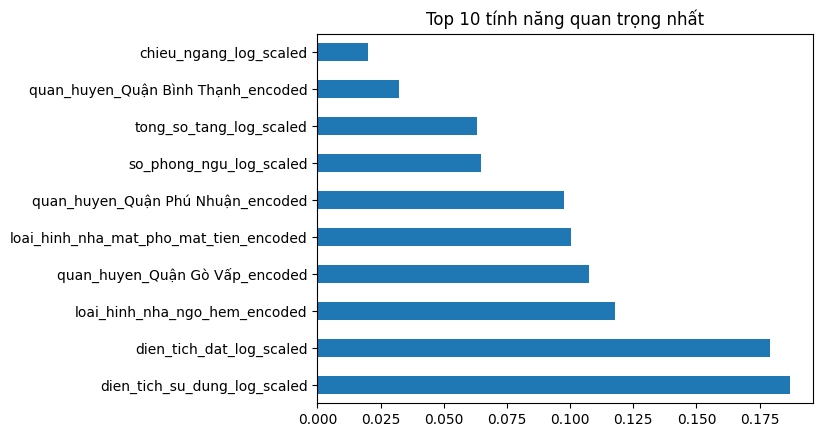

In [154]:
# 1. Tìm vị trí của XGBoost trong danh sách model_names
# Thường thì XGBoost của m nằm ở vị trí thứ 2 (index 2)
idx = model_names.index("XGBoost")

# 2. Lấy cái Pipeline của XGBoost ra
best_pipe = trained_models[idx]

# 3. Vì mình dùng Pipeline, nên phải chọc vào bước 'model' để lấy XGBoost thực sự
# (Nếu m đã sửa Pipeline theo cách t chỉ là bỏ Scaler cho XGBoost)
best_model = best_pipe.named_steps['model']

# 4. Bây giờ mới lấy độ quan trọng (Feature Importance)
importance = best_model.feature_importances_

# 5. Vẽ biểu đồ để xem Model nó có thực sự nhìn vào Diện Tích không
feat_importances = pd.Series(importance, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 tính năng quan trọng nhất")
plt.show()

In [155]:
print(df_transformed.columns.tolist())

['tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'tong_so_tang', 'so_phong_ngu', 'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 'quan_huyen', 'gia_ban', 'dien_tich_dat_log', 'dien_tich_su_dung_log', 'chieu_ngang_log', 'gia_ban_log', 'tong_so_tang_log', 'so_phong_ngu_log', 'y_pred', 'residual', 'residual_z', 'violate_min_max', 'is_iso_outlier', 'res_z_norm', 'final_anomaly_score', 'm_min', 'm_max']


In [156]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Tạo list chứa kết quả
results_list = []

for model, name in zip(trained_models, model_names):
    # Dự báo trên tập Test
    y_pred_log = model.predict(X_test)
    
    # Đưa về giá trị thực (tỷ đồng)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    # Tính toán các chỉ số
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    results_list.append({
        "Model": name,
        "R2 Score": f"{r2:.4f}",
        "MAE (Tỷ)": f"{mae:.2f}",
        "RMSE (Tỷ)": f"{rmse:.2f}"
    })

# 2. In bảng
df_compare = pd.DataFrame(results_list).sort_values("R2 Score", ascending=False)
print("--- KẾT QUẢ SO SÁNH ---")
display(df_compare)

--- KẾT QUẢ SO SÁNH ---


,Model,R2 Score,MAE (Tỷ),RMSE (Tỷ)
2,XGBoost,0.7523,1.19,1.93
1,Random Forest Regressor,0.7503,1.22,1.94
3,LightGBM Regressor,0.7486,1.23,1.95
4,Gradient-Boosted Trees Regressor,0.7295,1.26,2.02
0,Linear Regression,0.7116,1.33,2.09


In [157]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# 1. CHỌN MODEL TỐT NHẤT
try:
    best_ml_model = trained_models[2]
except:
    best_ml_model = models[2]

# 2. DỰ BÁO VÀ TÍNH SAI SỐ
y_pred_raw = best_ml_model.predict(X) 
lam = 0.23
y_pred_real = (y_pred_raw * lam + 1) ** (1 / lam)
y_true_real = (y * lam + 1) ** (1 / lam) 

df_transformed['y_pred'] = y_pred_real
df_transformed['residual'] = y_true_real - y_pred_real

# 3. TÍNH RESIDUAL-Z (An toàn: Nếu lỗi thì trả về 0)
def get_z_score(x):
    if len(x) <= 1 or x.std() == 0: return 0
    return (x - x.mean()) / x.std()

df_transformed['residual_z'] = df_transformed.groupby(['quan_huyen', 'loai_hinh'])['residual'].transform(get_z_score).fillna(0)

# 4. KHOẢNG GIÁ THỊ TRƯỜNG (Tính thủ công để tránh Merge lỗi)
group_stats = df_transformed.groupby(['quan_huyen', 'loai_hinh'])['gia_ban'].agg(['min', 'max']).reset_index()
df_transformed = df_transformed.drop(columns=['m_min', 'm_max'], errors='ignore')
df_transformed = df_transformed.merge(group_stats, on=['quan_huyen', 'loai_hinh'], how='left')
df_transformed.rename(columns={'min': 'm_min', 'max': 'm_max'}, inplace=True)

# Đánh dấu vi phạm (Dùng fillna để tránh mất dòng)
df_transformed['violate_min_max'] = ((df_transformed['gia_ban'] <= df_transformed['m_min']) | 
                                      (df_transformed['gia_ban'] >= df_transformed['m_max'])).fillna(0).astype(int)

# 5. UNSUPERVISED (Isolation Forest)
iso = IsolationForest(contamination=0.05, random_state=42)
# Đảm bảo không có giá trị vô hạn hoặc NaN
iso_data = df_transformed[['dien_tich_dat', 'gia_ban', 'residual_z']].fillna(0).replace([np.inf, -np.inf], 0)
df_transformed['is_iso_outlier'] = (iso.fit_predict(iso_data) == -1).astype(int)

# 6. TÍNH ĐIỂM TỔNG HỢP
scaler = MinMaxScaler()
res_z_abs = df_transformed[['residual_z']].abs().fillna(0)
df_transformed['res_z_norm'] = scaler.fit_transform(res_z_abs)

# Tính tổng điểm
df_transformed['final_anomaly_score'] = (
    df_transformed['res_z_norm'] * 0.5 + 
    df_transformed['violate_min_max'] * 0.25 + 
    df_transformed['is_iso_outlier'] * 0.25
) * 100

# ---------------------------------------------------------------------------
# KIỂM TRA LỖI (BƯỚC QUAN TRỌNG)
# ---------------------------------------------------------------------------
print("--- THỐNG KÊ CÁC CỘT ĐIỂM ---")
print(df_transformed[['residual_z', 'violate_min_max', 'is_iso_outlier', 'final_anomaly_score']].describe().loc[['max', 'mean']])

# Sắp xếp và lấy Top 5% (khoảng 203 căn)
num_anomalies = int(len(df_transformed) * 0.05)
target_list = df_transformed.sort_values(by='final_anomaly_score', ascending=False).head(num_anomalies)

print(f"\n--- KẾT QUẢ ---")
print(f"Tổng số tin đăng: {len(df_transformed)}")
print(f"Số tin đăng bất thường lấy ra: {len(target_list)}")

if len(target_list) > 0:
    display(target_list[['tieu_de', 'quan_huyen', 'gia_ban', 'residual_z', 'final_anomaly_score']].head(20))
else:
    print("Vẫn ra 0? Hãy kiểm tra xem biến 'df_transformed' có bị trống không.")

--- THỐNG KÊ CÁC CỘT ĐIỂM ---
        residual_z  violate_min_max  is_iso_outlier  final_anomaly_score
max   7.832555e+00         1.000000        1.000000             75.00000
mean -1.495683e-17         0.003684        0.049862              5.91954

--- KẾT QUẢ ---
Tổng số tin đăng: 7601
Số tin đăng bất thường lấy ra: 380


,tieu_de,quan_huyen,gia_ban,residual_z,final_anomaly_score
6454,Hoàng Văn Thụ – Nhà Mới 5 Tầng -6PN Có Thang Máy,Quận Gò Vấp,21.70,7.832555,75.000000
1104,BÁN NHÀ CHÍNH CHỦ KHU CĂN CỨ 26 DT 10 X19 M,Quận Gò Vấp,24.80,3.732643,73.827528
4534,💥 SIÊU PHẨM CÓ 1–0–2 BÌNH THẠNH – LÔ GÓC KINH ...,Quận Bình Thạnh,23.00,3.140272,70.046030
4322,Nhà mặt tiền đường Phan Văn Trị,Quận Bình Thạnh,25.00,3.039671,69.403826
3274,"Cần bán nhà hẻm đường Đào Duy Anh, P.9, Q. Phú...",Quận Phú Nhuận,25.00,2.953264,68.852232
6347,"Tặng iPhone 17, Cityland Park Hill, Nguyễn Văn...",Quận Gò Vấp,25.00,2.806779,67.917121
3559,"Homestay Garden 11Phong,Dòng Tiền 1ty5/nam,110...",Quận Bình Thạnh,25.20,2.578752,66.461473
2275,"Mặt tiền 05 tầng Có THANG MÁY Trần Thị Nghỉ, 5...",Quận Gò Vấp,25.50,2.534239,66.177317
457,NHÀ 99M2 - 3PN SẴN DÒNG TIỀN ❌ NƠ TRANG LONG B...,Quận Bình Thạnh,4.36,-6.059803,63.683343
6100,5 × 18 HẺM 8M - NHÀ 2 TẦNG GÒ VẤP - PHAN VĂN T...,Quận Gò Vấp,15.00,6.043736,63.580771



**Nhận xét:**\
**XGBoost là model tốt nhất so với các model còn lại (xét theo RMSE, MAE thấp nhất, R-squared cao nhất)**

| Model                                                | R-squared | MAE       | RMSE      |
| :--------------------------------------------------- | :-------- | :-------- | :-------- |
| Linear Regression                                    | 0.674     | 0.653     | 0.833     |
| Random Forest Regressor                              | 0.740     | 0.561     | 0.743     |
| **XGBoost**                                              | **0.747**     | **0.549**     | **0.733**     |
| LightGBM                                             | 0.737     | 0.566     | 0.747     |
| SVM (RBF Kernel)                                     | 0.422     | 0.855     | 1.108     |
| Gradient-Boosted Trees                               | 0.720     | 0.590     | 0.772     |


# **Bài toán số 2**

## Phương Pháp 1: Residual-Z

### Ý tưởng
Dùng XGBoost dự đoán giá → tính **sai số** giữa giá thực và giá dự đoán → chuẩn hóa thành Z-score.  
Căn nhà có **|Z| lớn** nghĩa là giá thực lệch xa so với mức mà thị trường "kỳ vọng" → bất thường.

### Công thức
$$e = y_{\text{thực tế}} - y_{\text{dự đoán}}$$
$$Z_{resid} = \frac{e - \bar{e}}{\sigma_e}$$
$$S_{resid} = \frac{|Z| - |Z|_{min}}{|Z|_{max} - |Z|_{min}} \quad \text{(clip tại |Z|=3)}$$

- Z > 0 → giá thực **cao hơn** dự đoán (có thể quá đắt)  
- Z < 0 → giá thực **thấp hơn** dự đoán (có thể quá rẻ)  
- |Z| > 2 → bất thường | |Z| > 3 → rất bất thường

#### **Khai báo hàm**

In [158]:
def detect_real_estate_anomalies_by_residual_z(df, groupby_features):
    # 1. Tính sai số (residual)
    df['residual'] = df['gia_ban'] - df['final_prediction']

    # 2. Tính Trung bình và Độ lệch chuẩn của residual theo từng nhóm (Window function)
    # transform() giúp giữ nguyên số lượng dòng của dataframe gốc
    df['avg_res'] = df.groupby(groupby_features)['residual'].transform('mean')
    df['std_res'] = df.groupby(groupby_features)['residual'].transform('std')

    # 3. Tính Z-score của sai số
    # Thêm 1 lượng cực nhỏ (1e-9) vào mẫu số để tránh lỗi chia cho 0 nếu std = 0
    df['residual_z'] = (df['residual'] - df['avg_res']) / (df['std_res'] + 1e-9)

    # 4. Đánh dấu vi phạm (Outliers) nếu |Z| > 3
    df['violate_residual_z'] = np.where(df['residual_z'].abs() > 3, 1, 0)

    return df

In [159]:
def composite_scores(df, groupby_features, methods,
                     threshold_pr_min=None, threshold_pr_max=None,
                     threshold_po_min=None, threshold_po_max=None,
                     feature_cols=None, isf_contamination=0.05):

    df_anomalies = df.copy()

    # 1. Chạy các phương pháp phát hiện dựa trên danh sách keys của methods
    for method in methods.keys():
        if method == "residual_z":
            df_anomalies = detect_real_estate_anomalies_by_residual_z(df_anomalies, groupby_features)
        elif method == "min_max":
            df_anomalies = detect_real_estate_anomalies_by_min_max(df_anomalies, groupby_features, threshold_pr_min, threshold_pr_max)
        elif method == "outside_conf":
            df_anomalies = detect_real_estate_anomalies_by_outside_conf(df_anomalies, groupby_features, threshold_po_min, threshold_po_max)
        elif method == "isolation_forest":
            df_anomalies = detect_real_estate_anomalies_by_isolation_forest(df_anomalies, groupby_features, feature_cols, isf_contamination)

    # 2. Tính điểm tổng hợp (Weighted Score)
    # Khởi tạo cột điểm bằng 0
    df_anomalies['raw_anomaly_score'] = 0.0

    for method, weights in methods.items():
        for col_name, weight in weights.items():
            if col_name in df_anomalies.columns:
                df_anomalies['raw_anomaly_score'] += df_anomalies[col_name] * weight

    # 3. Chuẩn hóa về thang điểm 100
    max_val = df_anomalies['raw_anomaly_score'].max()

    if max_val == 0 or pd.isna(max_val):
        df_anomalies['final_anomaly_score'] = 0.0
    else:
        df_anomalies['final_anomaly_score'] = (df_anomalies['raw_anomaly_score'] / max_val) * 100

    return df_anomalies

In [160]:
def extract_anomalies(df, threshold_outlier_percent):
    df_anomalies = df
    ceiling_score = df_anomalies.stat.approxQuantile("final_anomaly_score", [1-threshold_outlier_percent], 0.0)[0]
    list_anomalies = df_anomalies.filter(F.col("final_anomaly_score") >= ceiling_score) \
                                .select(df_anomalies.columns).orderBy(F.desc("final_anomaly_score"))
    return list_anomalies

In [161]:
def report_anomalies(df, groupby_features, methods, methods_features, methods_flags,
                     threshold_outlier_percent, threshold_pr_min=None,
                     threshold_pr_max=None, threshold_po_min=None,
                     threshold_po_max=None, feature_cols=None, isf_contamination=None):

    # Tính toán điểm tổng hợp
    df_anomalies = composite_scores(df, groupby_features, methods,
                                   threshold_pr_min, threshold_pr_max,
                                   threshold_po_min, threshold_po_max,
                                   feature_cols, isf_contamination)

    # Trích xuất anomalies theo percentile
    list_anomalies = extract_anomalies(df_anomalies, threshold_outlier_percent)

    # Tạo điều kiện lọc (Combined Condition): Chỉ lấy những dòng có ít nhất 1 flag vi phạm
    # Trong Pandas, dùng (df[flags] == 1).any(axis=1) thay cho reduce(|)
    combined_condition = (list_anomalies[methods_flags] == 1).any(axis=1)
    list_anomalies = list_anomalies[combined_condition]

    # Xác định các cột cần hiển thị
    # Sử dụng list để gom nhóm các cột tránh trùng lặp
    base_columns = ["gia_ban", "final_prediction"]
    info_columns = ["dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "tong_so_tang",
                    "so_phong_ngu", "giay_to_phap_ly", "tinh_trang_noi_that", "dac_diem",
                    "dia_chi_cu", "dia_chi_moi"]

    selected_columns = (base_columns +
                        (methods_features if methods_features else []) +
                        methods_flags +
                        ["final_anomaly_score"] +
                        groupby_features +
                        info_columns)

    # Lọc các cột hiện có trong DataFrame để tránh lỗi KeyNotFound
    selected_columns = [c for c in selected_columns if c in list_anomalies.columns]

    # Sắp xếp (OrderBy)
    orderby_features = ["final_anomaly_score"] + groupby_features + (methods_features if methods_features else [])
    # Sắp xếp giảm dần cho toàn bộ các cột tiêu chí
    list_anomalies = list_anomalies[selected_columns].sort_values(
        by=orderby_features,
        ascending=False
    )

    # Hiển thị kết quả
    print(f"Số lượng nhà bất thường phát hiện: {len(list_anomalies)}")
    # Hiển thị 20 dòng đầu tiên tương tự .show() của Spark
    if not list_anomalies.empty:
        print(list_anomalies.head(20).to_string())

    return df_anomalies, list_anomalies

**Biểu đồ Scatter: Giá thực tế vs Giá dự đoán (Highlight Outliers)**

Biểu đồ này giúp ta thấy rõ những căn nhà có sai số cực lớn (nằm xa đường chéo)

In [162]:
def scatter_highlight_outliers(df_anomalies, list_anomalies, sample_frac=0.1):
    """
    Vẽ biểu đồ Scatter Plot để trực quan hóa dữ liệu bất thường trên nền dữ liệu mẫu.
    """
    # 1. Lấy mẫu dữ liệu nền (Normal Data) để tránh quá tải biểu đồ nếu dữ liệu lớn
    # Nếu dữ liệu nhỏ, bạn có thể đặt sample_frac=1.0
    pdf_sample = df_anomalies.sample(frac=sample_frac, random_state=42)

    # 2. Dữ liệu bất thường đã là Pandas nên không cần chuyển đổi
    pdf_anomalies = list_anomalies

    plt.figure(figsize=(12, 8))

    # 3. Vẽ dữ liệu bình thường (Màu xám, độ trong suốt thấp)
    sns.scatterplot(
        data=pdf_sample,
        x='final_prediction',
        y='gia_ban',
        alpha=0.3,
        label='Dữ liệu mẫu (Normal)',
        color='gray'
    )

    # 4. Highlight dữ liệu bất thường (Màu đỏ, kích thước lớn hơn)
    sns.scatterplot(
        data=pdf_anomalies,
        x='final_prediction',
        y='gia_ban',
        color='red',
        label='Bất thường (Anomalies)',
        s=100,
        edgecolor='black'
    )

    # 5. Vẽ đường chéo lý tưởng (Y = X)
    # Tìm giá trị lớn nhất của cả 2 trục để vẽ đường cân bằng
    all_max = max(
        pdf_sample[['gia_ban', 'final_prediction']].max().max(),
        pdf_anomalies[['gia_ban', 'final_prediction']].max().max()
    )
    plt.plot([0, all_max], [0, all_max], '--', color='blue', alpha=0.5, label='Đường lý tưởng')

    # 6. Định dạng biểu đồ
    plt.title("Phát hiện bất thường: Giá thực tế vs Giá dự đoán", fontsize=15)
    plt.xlabel("Giá dự đoán (Model Prediction)", fontsize=12)
    plt.ylabel("Giá thực tế (Actual Price)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [163]:
def visualize_anomalies_by_selected_features(df, methods_flags):
    # Chỉ lấy các cột cần thiết và chuyển về Pandas để nhẹ bộ nhớ
    # Giả sử is_anomaly_iforest: 1 là bất thường (đỏ), 0 là bình thường (xanh)
    pdf = df.select(
        "quan_huyen_loai_hinh",
        "giay_to_phap_ly",
        "gia_ban",
        *methods_flags
    ).toPandas()

    # Khởi tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Biểu đồ phân cụm các điểm bất thường', fontsize=13, fontweight='bold')

    # Định nghĩa bảng màu
    # 1 (Bất thường) -> Đỏ
    # 0 (Bình thường) -> Xanh

    pdf['is_any_anomaly'] = pdf[methods_flags].max(axis=1)
    pdf_sorted = pdf.sort_values(by='is_any_anomaly', ascending=True)
    combined_colors = pdf_sorted['is_any_anomaly'].map({1: '#D32F2F', 0: '#4CAF50'})
    point_sizes = pdf_sorted['is_any_anomaly'].map({1: 30, 0: 15})
    # Biểu đồ 1: Quận/ huyện - Loại hình vs Giá
    axes[0].scatter(
        pdf['quan_huyen_loai_hinh'],
        pdf['gia_ban'],
        c=combined_colors,
        s=point_sizes,
        alpha=0.5
    )
    axes[0].set_title('Quận huyện & loại hình vs Giá\n(đỏ = bất thường)')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Giá bán')
    axes[0].tick_params(axis='x', rotation=45)
    for label in axes[0].get_xticklabels():
        label.set_horizontalalignment('right')

    # Biểu đồ 2: Diện tích vs Giá
    axes[1].scatter(
        pdf['giay_to_phap_ly'],
        pdf['gia_ban'],
        c=combined_colors,
        s=point_sizes,
        alpha=0.5
    )
    axes[1].set_title('Tình trạng pháp lý vs Giá\n(đỏ = bất thường)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Giá bán')
    axes[1].tick_params(axis='x', rotation=45)
    for label in axes[1].get_xticklabels():
        label.set_horizontalalignment('right')

    plt.tight_layout()
    plt.show()


#### **Thực thi Residual-z**

### Residual-z chuẩn hóa sai số theo 'loai_hinh' vì mức độ biến động giá khác nhau rõ rệt giữa các loại hình

In [164]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# --- BƯỚC 1: DỰ BÁO GIÁ (DÙNG XGBOOST) ---
try:
    best_ml_model = trained_models[2] # XGBoost
except:
    best_ml_model = models[2]

y_pred_raw = best_ml_model.predict(X)
lam = 0.23
y_pred_real = (y_pred_raw * lam + 1) ** (1 / lam)
y_true_real = (y * lam + 1) ** (1 / lam)

df_transformed['y_pred'] = y_pred_real
df_transformed['residual'] = y_true_real - y_pred_real

# --- BƯỚC 2: TÍNH TOÁN CÁC CHỈ SỐ BẤT THƯỜNG ---

# Residual-z: So sánh sai số theo từng Phường và Loại hình
def safe_z_score(group):
    if len(group) <= 1 or group.std() == 0: return 0
    return (group - group.mean()) / group.std()

df_transformed['residual_z'] = df_transformed.groupby(['quan_huyen', 'loai_hinh'])['residual'].transform(safe_z_score).fillna(0)

# Vi phạm Min/Max khu vực
group_stats = df_transformed.groupby(['quan_huyen', 'loai_hinh'])['gia_ban'].agg(['min', 'max']).reset_index()
df_transformed = df_transformed.drop(columns=['m_min', 'm_max'], errors='ignore')
df_transformed = df_transformed.merge(group_stats, on=['quan_huyen', 'loai_hinh'], how='left').rename(columns={'min': 'm_min', 'max': 'm_max'})

df_transformed['violate_min_max'] = ((df_transformed['gia_ban'] <= df_transformed['m_min']) | 
                                      (df_transformed['gia_ban'] >= df_transformed['m_max'])).astype(int)

# Isolation Forest (Unsupervised)
iso = IsolationForest(contamination=0.05, random_state=42)
df_transformed['is_iso_outlier'] = (iso.fit_predict(df_transformed[['dien_tich_dat', 'gia_ban', 'residual_z']].fillna(0)) == -1).astype(int)

# --- BƯỚC 3: TÍNH ĐIỂM TỔNG HỢP ---
scaler = MinMaxScaler()
df_transformed['res_z_norm'] = scaler.fit_transform(df_transformed[['residual_z']].abs())

df_transformed['final_anomaly_score'] = (
    df_transformed['res_z_norm'] * 0.5 + 
    df_transformed['violate_min_max'] * 0.25 + 
    df_transformed['is_iso_outlier'] * 0.25
) * 100

# Lấy Top 5%
num_anomalies = int(len(df_transformed) * 0.05)
target_list = df_transformed.sort_values(by='final_anomaly_score', ascending=False).head(num_anomalies)

print(f"Đã xác định {len(target_list)} căn nhà bất thường.")

Đã xác định 380 căn nhà bất thường.


In [165]:
# Tạo cột phân loại lý do bất thường để dễ nhìn
def classify_reason(row):
    reasons = []
    if row['res_z_norm'] > 0.6: # Residual cao
        if row['residual'] > 0: reasons.append("Giá cao bất thường (Ngáo giá)")
        else: reasons.append("Giá thấp bất thường (Tin ảo/Ngộp)")
    if row['violate_min_max'] == 1:
        reasons.append("Vượt khung giá khu vực")
    if row['is_iso_outlier'] == 1:
        reasons.append("Đặc điểm diện tích/giá lạ (Outlier)")
    
    return " + ".join(reasons) if reasons else "Sai số tổng hợp"

# Áp dụng phân loại
target_list['ly_do_bat_thuong'] = target_list.apply(classify_reason, axis=1)

# Hiển thị bảng chi tiết để bạn check
print("\n--- BẢNG PHÂN TÍCH CHI TIẾT LÝ DO BẤT THƯỜNG ---")
display(target_list[['tieu_de', 'quan_huyen', 'gia_ban', 'residual_z', 'ly_do_bat_thuong', 'final_anomaly_score']]
        .sort_values(by='final_anomaly_score', ascending=False)
        .head(15))


--- BẢNG PHÂN TÍCH CHI TIẾT LÝ DO BẤT THƯỜNG ---


,tieu_de,quan_huyen,gia_ban,residual_z,ly_do_bat_thuong,final_anomaly_score
6454,Hoàng Văn Thụ – Nhà Mới 5 Tầng -6PN Có Thang Máy,Quận Gò Vấp,21.70,7.832555,Giá cao bất thường (Ngáo giá) + Đặc điểm diện ...,75.000000
1104,BÁN NHÀ CHÍNH CHỦ KHU CĂN CỨ 26 DT 10 X19 M,Quận Gò Vấp,24.80,3.732643,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,73.827528
4534,💥 SIÊU PHẨM CÓ 1–0–2 BÌNH THẠNH – LÔ GÓC KINH ...,Quận Bình Thạnh,23.00,3.140272,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,70.046030
4322,Nhà mặt tiền đường Phan Văn Trị,Quận Bình Thạnh,25.00,3.039671,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,69.403826
3274,"Cần bán nhà hẻm đường Đào Duy Anh, P.9, Q. Phú...",Quận Phú Nhuận,25.00,2.953264,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,68.852232
6347,"Tặng iPhone 17, Cityland Park Hill, Nguyễn Văn...",Quận Gò Vấp,25.00,2.806779,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,67.917121
3559,"Homestay Garden 11Phong,Dòng Tiền 1ty5/nam,110...",Quận Bình Thạnh,25.20,2.578752,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,66.461473
2275,"Mặt tiền 05 tầng Có THANG MÁY Trần Thị Nghỉ, 5...",Quận Gò Vấp,25.50,2.534239,Vượt khung giá khu vực + Đặc điểm diện tích/gi...,66.177317
457,NHÀ 99M2 - 3PN SẴN DÒNG TIỀN ❌ NƠ TRANG LONG B...,Quận Bình Thạnh,4.36,-6.059803,Giá thấp bất thường (Tin ảo/Ngộp) + Đặc điểm d...,63.683343
6100,5 × 18 HẺM 8M - NHÀ 2 TẦNG GÒ VẤP - PHAN VĂN T...,Quận Gò Vấp,15.00,6.043736,Giá cao bất thường (Ngáo giá) + Đặc điểm diện ...,63.580771


In [166]:
import joblib
from sklearn.preprocessing import MinMaxScaler

# 1. Giả sử X_train của bạn đã bị Scale (giá trị từ 0 đến 1)
# Chúng ta sẽ dùng chính Scaler CŨ để nghịch đảo (inverse) nó về giá trị m2 ban đầu
# (Nếu bạn còn giữ biến 'scaler' cũ đã dùng để train model)

try:
    # Lấy 5 cột số từ X_train (thay tên cột cho đúng với bảng của bạn)
    num_cols_in_X = [c for c in X_train.columns if any(k in c.lower() for k in ['dien_tich', 'chieu_ngang', 'tang', 'phong_ngu'])]
    
    # Tạo một bảng nháp chứa dữ liệu thực tế (chưa scale)
    # Nếu bạn không có df_goc, hãy thử dùng tập X chưa scale (nếu còn biến đó)
    # Hoặc đơn giản là fit lại Scaler vào tập dữ liệu TRƯỚC KHI bạn scale nó.
    
    # CÁCH CHẮC CHẮN NHẤT: Tìm biến DataFrame nào chứa diện tích đất là 40, 50, 100...
    # Thay 'df_cua_ban' bằng tên biến đó (ví dụ: df_cleaned, df_final...)
    target_df = df_cleaned 
    
    num_cols_raw = ['dien_tich_dat', 'dien_tich_su_dung_boxcox', 'chieu_ngang_boxcox', 'tong_so_tang_boxcox', 'so_phong_ngu_sqrt']
    
    chuan_scaler = MinMaxScaler()
    chuan_scaler.fit(target_df[num_cols_raw])
    
    print("Max diện tích đất học được:", chuan_scaler.data_max_[0])
    
    # 2. Xuất file
    joblib.dump(chuan_scaler, 'scaler.pkl')
    joblib.dump(real_model, 'xgboost_model.pkl')
    joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')
    print("--- ĐÃ XUẤT FILE THÀNH CÔNG ---")

except NameError:
    print("Bạn hãy kiểm tra lại xem biến chứa dữ liệu m2 thực tế tên là gì nhé!")

Bạn hãy kiểm tra lại xem biến chứa dữ liệu m2 thực tế tên là gì nhé!


In [167]:
print("Giá trị Min của diện tích đất mà Scaler đã học:", scaler.data_min_[0])
print("Giá trị Max của diện tích đất mà Scaler đã học:", scaler.data_max_[0])

Giá trị Min của diện tích đất mà Scaler đã học: 6.60848311753362e-05
Giá trị Max của diện tích đất mà Scaler đã học: 7.832555275426808


In [168]:
def check_final_test(m2):
    # 1. Tạo DataFrame trống với đúng danh sách cột mà Model đã học (X_train.columns)
    test_df = pd.DataFrame(0, index=[0], columns=X_train.columns)
    
    # 2. Gán giá trị diện tích vào ĐÚNG tên cột mà model yêu cầu
    # Model của m yêu cầu tên là 'dien_tich_dat_log_scaled'
    test_df['dien_tich_dat_log_scaled'] = np.log1p(m2)
    test_df['dien_tich_su_dung_log_scaled'] = np.log1p(m2 * 1.2)
    
    # 3. Gán các đặc trưng khác nếu cần (để mặc định là 0 như trên là ổn)
    # Gán thử 1 quận để test, ví dụ Gò Vấp
    if 'quan_huyen_Quận Gò Vấp_encoded' in test_df.columns:
        test_df['quan_huyen_Quận Gò Vấp_encoded'] = 1
        
    # 4. Dự báo
    # Model của m là Pipeline nên nó sẽ tự xử lý nếu có bước Scaler bên trong
    pred_log = trained_models[2].predict(test_df)
    
    # 5. Giải mã log ra số tiền tỷ
    return np.expm1(pred_log)[0]

# Chạy kiểm tra thực tế
print(f"Nhà 50m2 dự báo: {check_final_test(50):.2f} tỷ")
print(f"Nhà 500m2 dự báo: {check_final_test(500):.2f} tỷ")

Nhà 50m2 dự báo: 6.19 tỷ
Nhà 500m2 dự báo: 13.41 tỷ


In [172]:
import joblib

# 1. Tìm đúng vị trí của XGBoost trong list model_names để lưu
# (Dù m có đổi thứ tự trong code thì dòng này vẫn sẽ tìm đúng XGBoost cho m)
try:
    xgb_idx = model_names.index("XGBoost")
    best_model = trained_models[xgb_idx]
    joblib.dump(best_model, 'model_real_estate_xgb.pkl')
    print(f"✅ Đã lưu Model: {model_names[xgb_idx]}")
except Exception as e:
    print(f"❌ Lỗi khi tìm XGBoost: {e}")

# 2. Lưu danh sách cột (Feature Names) - Cực kỳ quan trọng để giữ đúng thứ tự input
all_cols = X_train.columns.tolist()
joblib.dump(all_cols, 'feature_names.pkl')
print(f"✅ Đã lưu {len(all_cols)} tên cột vào feature_names.pkl")

# 3. Tự động trích xuất danh sách Quận và Loại hình chuẩn từ các cột đã encoded
# Việc này giúp Menu bên Streamlit tự khớp 100% với dữ liệu train
clean_loai_hinh = [c.replace('loai_hinh_', '').replace('_encoded', '') 
                   for c in all_cols if 'loai_hinh_' in c]

clean_quan_huyen = [c.replace('quan_huyen_', '').replace('_encoded', '') 
                    for c in all_cols if 'quan_huyen_' in c]

# Đóng gói vào 1 file để App load cho gọn
categories_dict = {
    'loai_hinh': clean_loai_hinh,
    'quan_huyen': clean_quan_huyen
}
joblib.dump(categories_dict, 'categories.pkl')

print(f"✅ Đã lưu danh mục vào categories.pkl")
print("--- TẤT CẢ FILE ĐÃ SẴN SÀNG ĐỂ SANG STREAMLIT ---")

✅ Đã lưu Model: XGBoost
✅ Đã lưu 12 tên cột vào feature_names.pkl
✅ Đã lưu danh mục vào categories.pkl
--- TẤT CẢ FILE ĐÃ SẴN SÀNG ĐỂ SANG STREAMLIT ---


In [174]:
print(data['tong_so_tang'].max())

8.0
